# In this notebook we are going to be analyzing and clustering the personality of customers

In [ ]:
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import missingno as missing
import math
from scipy.stats import mannwhitneyu
import scipy.stats as stats
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import shap
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture
from statsmodels.stats.power import NormalIndPower
from sklearn.inspection import PartialDependenceDisplay
import joblib
import os


warnings.filterwarnings("ignore")

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## First we are going to look into the data itself to see what we"re working with

In [3]:
dataset = pd.read_csv("./dataset/marketing_campaign.csv", sep="\t")
dataset.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Attributes

### People

- ID: Customer's unique identifier
- Year_Birth: Customer's birth year
- Education: Customer's education level
- Marital_Status: Customer's marital status
- Income: Customer's yearly household income
- Kidhome: Number of children in customer's household
- Teenhome: Number of teenagers in customer's household
- Dt_Customer: Date of customer's enrollment with the company
- Recency: Number of days since customer's last purchase
- Complain: 1 if the customer complained in the last 2 years, 0 otherwise

### Products

- MntWines: Amount spent on wine in last 2 years
- MntFruits: Amount spent on fruits in last 2 years
- MntMeatProducts: Amount spent on meat in last 2 years
- MntFishProducts: Amount spent on fish in last 2 years
- MntSweetProducts: Amount spent on sweets in last 2 years
- MntGoldProds: Amount spent on gold in last 2 years

### Promotion

- NumDealsPurchases: Number of purchases made with a discount
- AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
- AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
- AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
- AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
- AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
- Response: 1 if customer accepted the offer in the last campaign, 0 otherwise

### Place

- NumWebPurchases: Number of purchases made through the company’s website
- NumCatalogPurchases: Number of purchases made using a catalogue
- NumStorePurchases: Number of purchases made directly in stores
- NumWebVisitsMonth: Number of visits to company’s website in the last month

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

<Axes: >

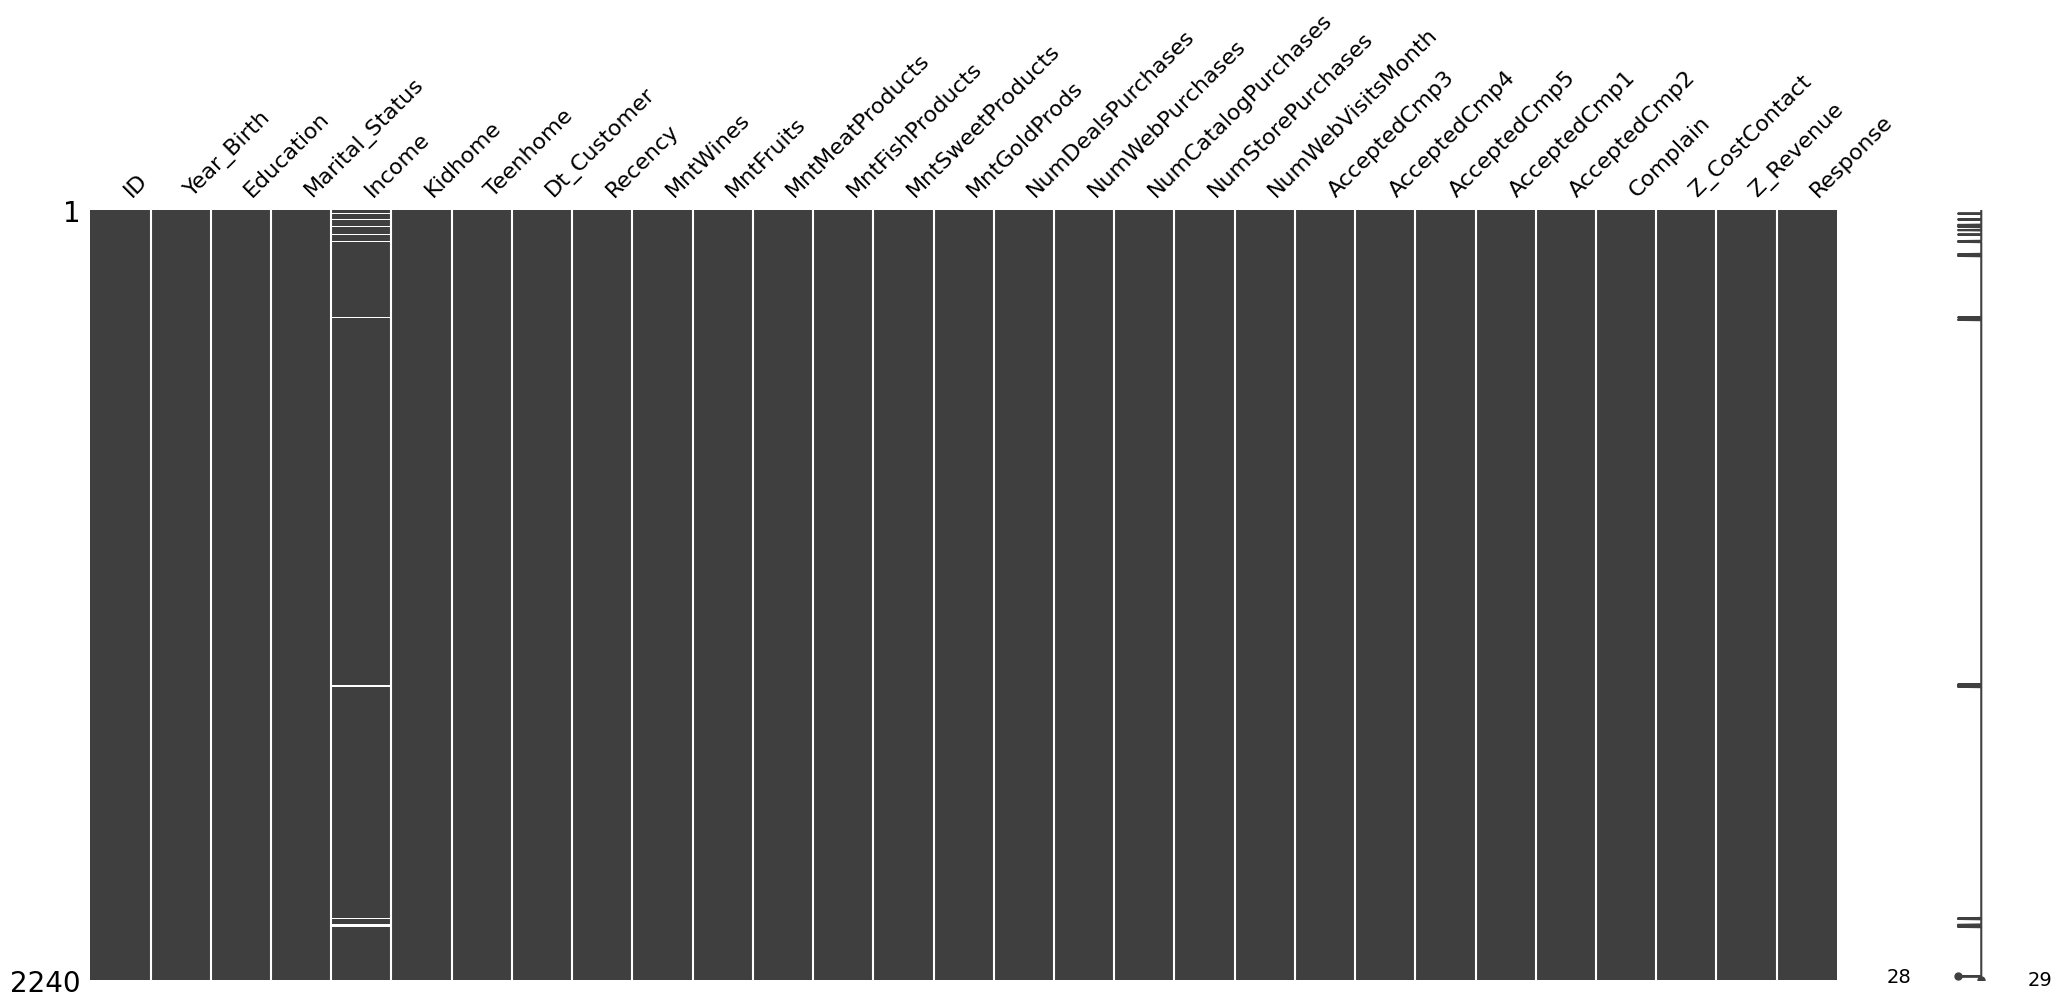

In [5]:
missing.matrix(dataset)

<Axes: >

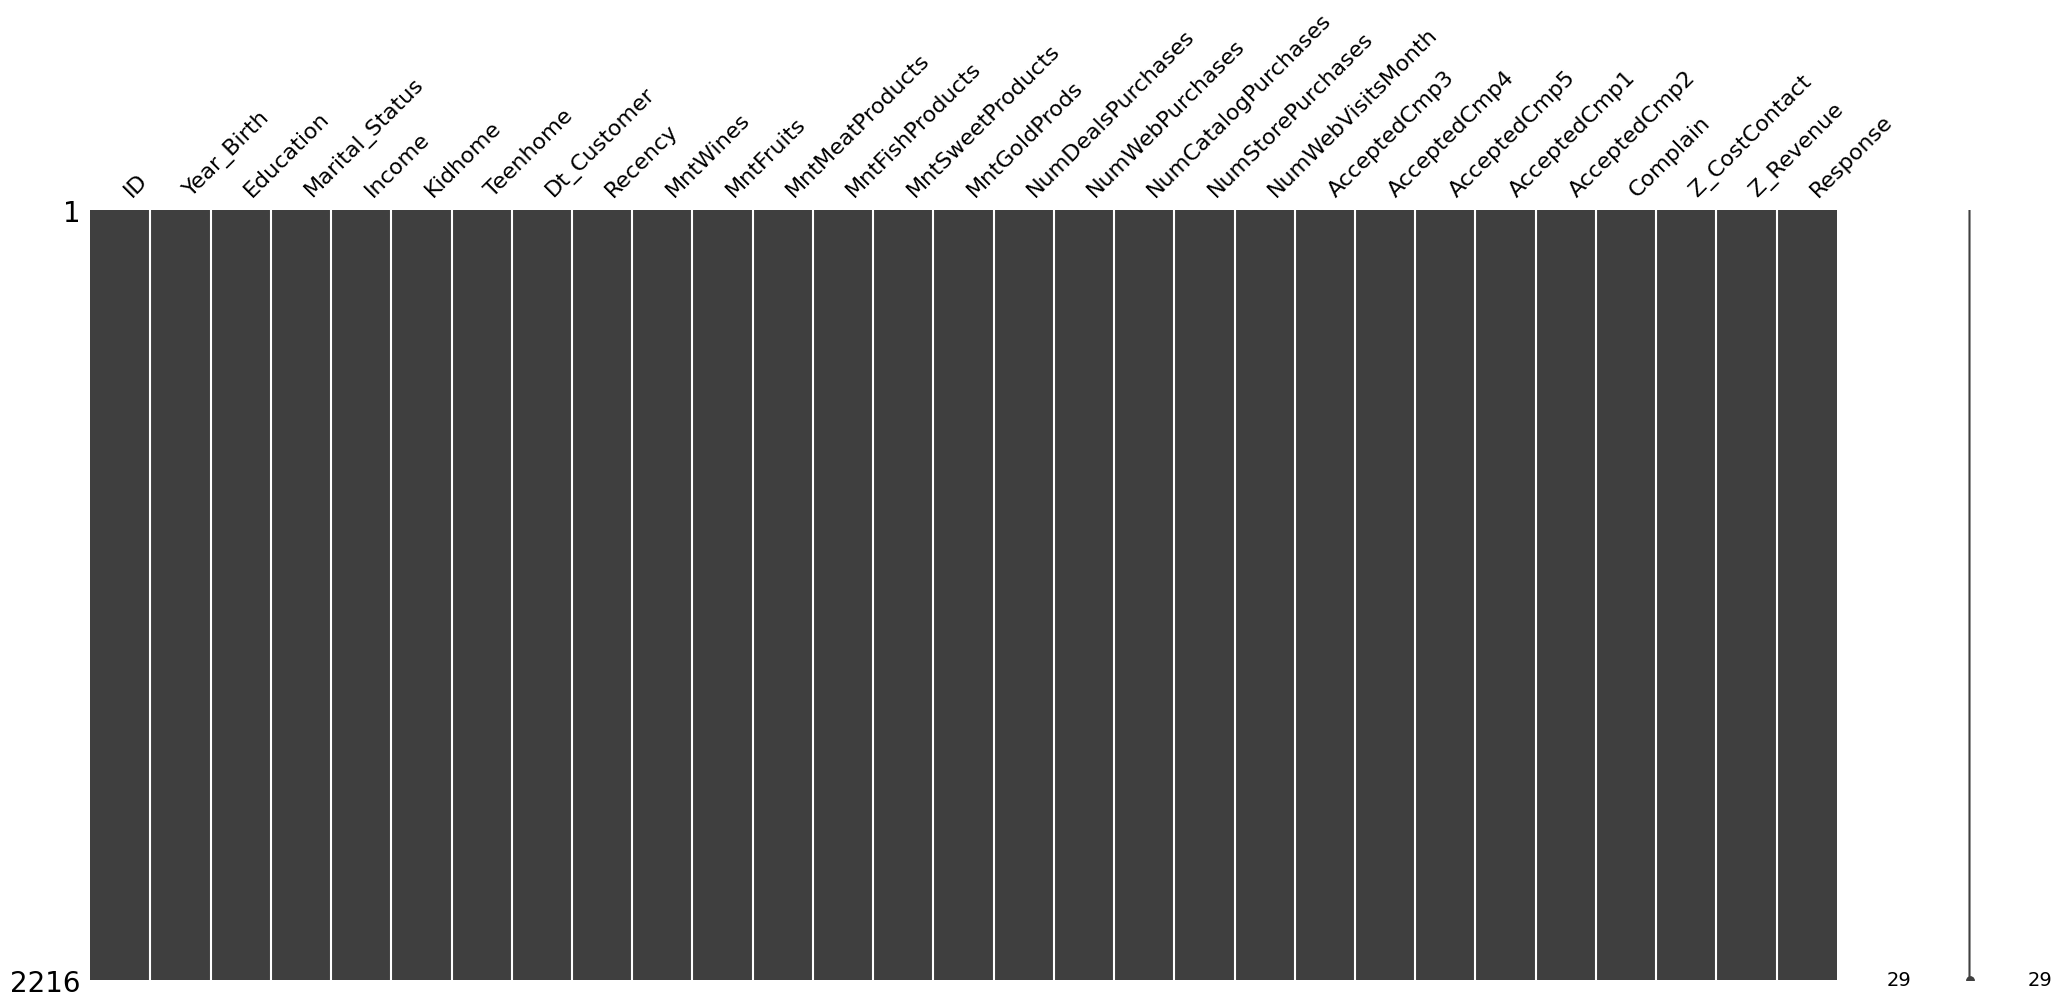

In [6]:
# We can see here that there are some missing values in the dataset, but they are not significant. We can drop them without losing much information.
dataset.dropna(inplace=True)
missing.matrix(dataset)

In [7]:
dataset.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [8]:
# We note here that Dt_customer is a date column, we can convert it to datetime format, we can also make an "age" column by subtracting the year of birth from the year of enrollment.
# We can also make a "children" column by adding the number of kids and teens together.
dataset["Children"] = dataset["Kidhome"] + dataset["Teenhome"]
dataset["Dt_Customer"] = pd.to_datetime(dataset["Dt_Customer"], dayfirst=True)
dataset["Age_at_enrollment"] = dataset["Dt_Customer"].dt.year - dataset["Year_Birth"]
dataset.Dt_Customer.dtypes.name

'datetime64[ns]'

In [9]:
dataset[["Age_at_enrollment","Children"]].describe()

,Age_at_enrollment,Children
count,2216.000000,2216.000000
mean,44.208032,0.947202
std,12.023812,0.749062
min,16.000000,0.000000
25%,36.000000,0.000000
50%,43.000000,1.000000
75%,54.000000,1.000000
max,121.000000,3.000000


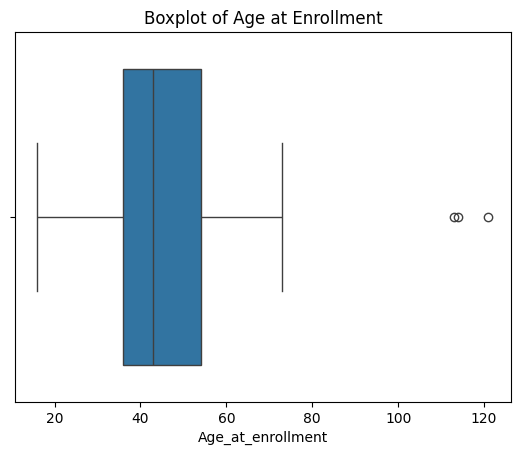

In [10]:
# As we can see in the table above, the average age is about 44 years old, the number of children about 1 and the maximum age at 121 seems unlikely, we can check the data to see if there are any outliers in the age column.
sns.boxplot(x=dataset["Age_at_enrollment"])
plt.title("Boxplot of Age at Enrollment")
plt.show()

In [11]:
# There are some outliers in the age column, we can check the data to see if there are any customers with age greater than 100 and less than 16, we can drop them as they are unlikely to be real customers.
outliers = dataset[(dataset["Age_at_enrollment"] > 100) | (dataset["Age_at_enrollment"] < 16)]
outliers.Age_at_enrollment

192    113
239    121
339    114
Name: Age_at_enrollment, dtype: int64

<Axes: xlabel='Age_at_enrollment'>

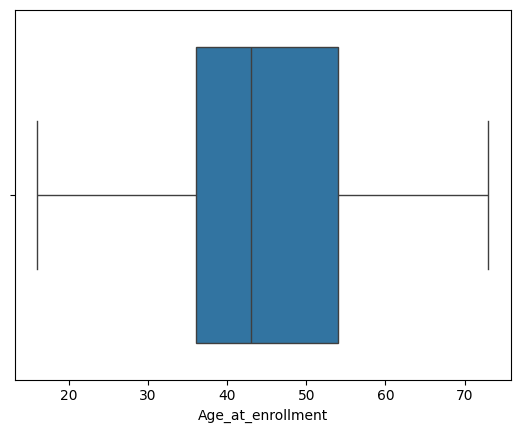

In [12]:
# There are few of them and they are unlikely to be real customers, we can drop them from the dataset.
dataset = dataset[(dataset["Age_at_enrollment"] <= 100) & (dataset["Age_at_enrollment"] >= 16)]
sns.boxplot(x=dataset["Age_at_enrollment"])

<Axes: xlabel='Income'>

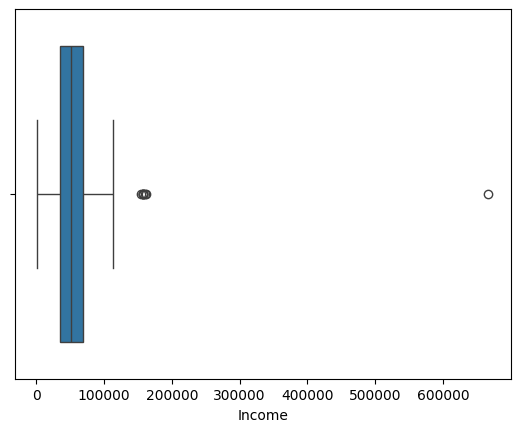

In [13]:
dataset["Income"].describe()
sns.boxplot(x=dataset["Income"])

In [14]:
outliers = dataset[(dataset["Income"] > 400000) | (dataset["Income"] < 1000)]
outliers.Income

2233    666666.0
Name: Income, dtype: float64

<Axes: xlabel='Income'>

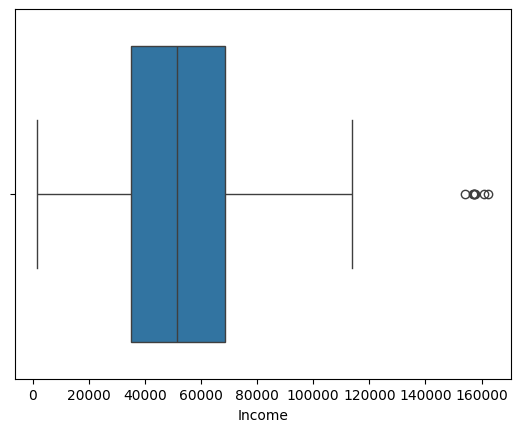

In [15]:
dataset = dataset[(dataset["Income"] <= 400000) & (dataset["Income"] >= 1000)]
sns.boxplot(x=dataset["Income"])

<Axes: xlabel='Income', ylabel='Count'>

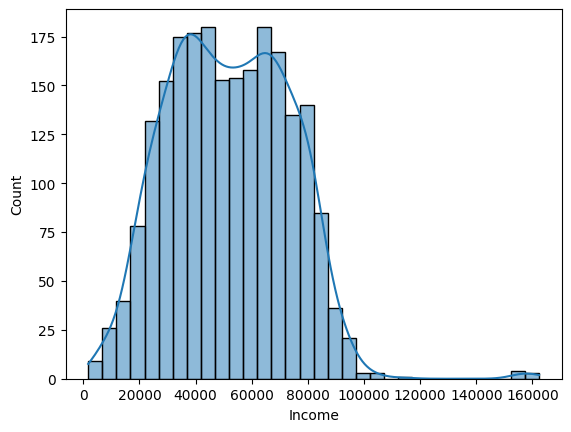

In [16]:
sns.histplot(x=dataset["Income"], kde=True)

<Axes: xlabel='Age_at_enrollment', ylabel='Count'>

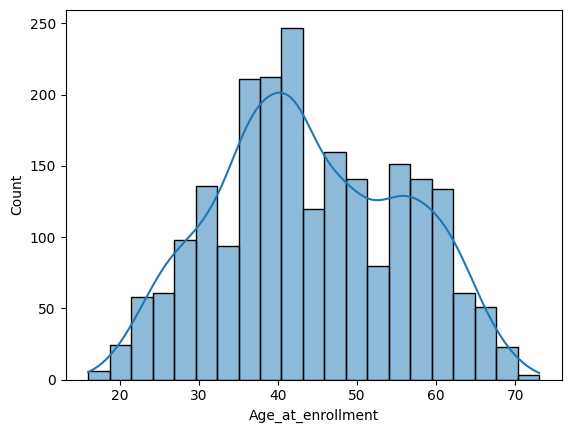

In [17]:
sns.histplot(x=dataset["Age_at_enrollment"], kde=True)

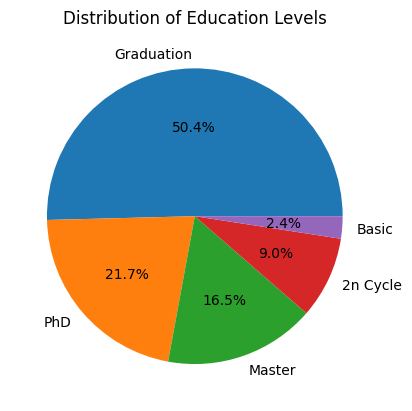

In [18]:
education_counts = dataset["Education"].value_counts()

plt.figure()
plt.pie(education_counts, labels=education_counts.index, autopct="%1.1f%%")

plt.title("Distribution of Education Levels")
plt.show()

In [19]:
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
dataset["Total_Spending"] = dataset[spending_cols].sum(axis=1)
dataset["Total_Spending"].describe()

count    2212.000000
mean      607.268083
std       602.513364
min         5.000000
25%        69.000000
50%       397.000000
75%      1048.000000
max      2525.000000
Name: Total_Spending, dtype: float64

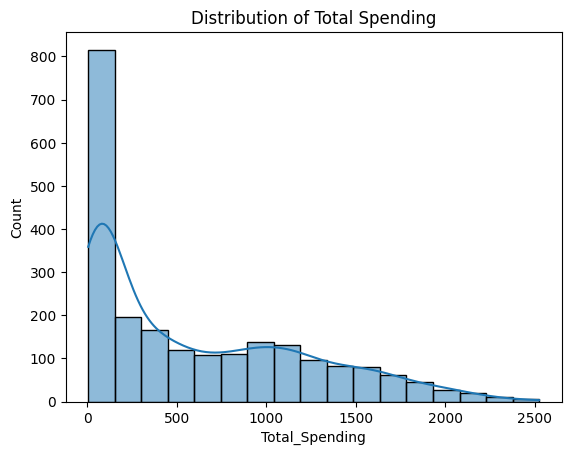

In [20]:
sns.histplot(x=dataset["Total_Spending"], kde=True)
plt.title("Distribution of Total Spending")
plt.show()

In [21]:
dataset["Recency"].describe()

count    2212.000000
mean       49.019439
std        28.943121
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: Recency, dtype: float64

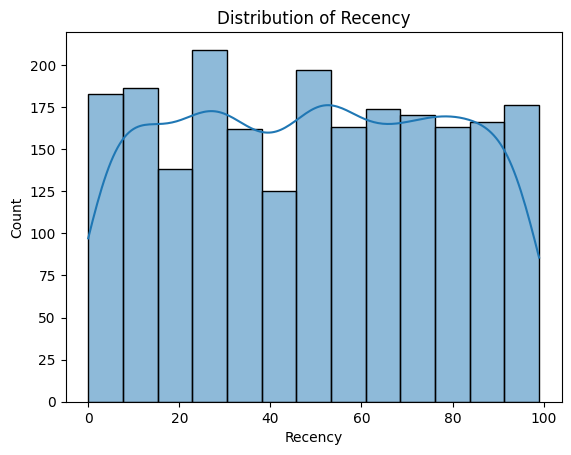

In [22]:
sns.histplot(x=dataset["Recency"], kde=True)
plt.title("Distribution of Recency")
plt.show()

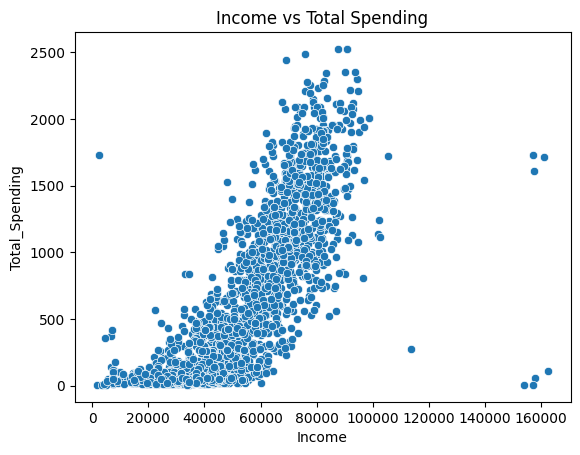

In [23]:
sns.scatterplot(x=dataset["Income"], y=dataset["Total_Spending"])
plt.title("Income vs Total Spending")
plt.show()

As expected we can observe a very clear relation between total spending and income in most cases

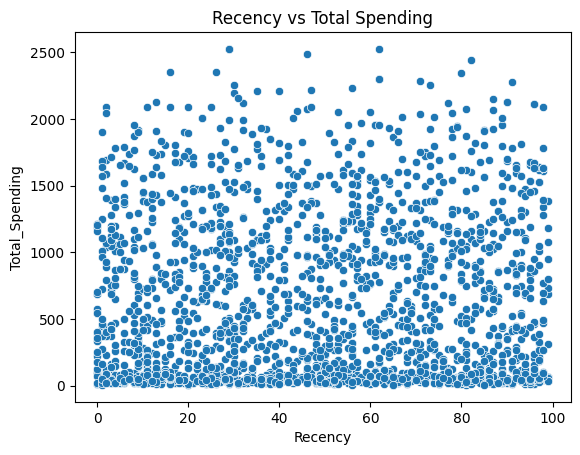

In [24]:
sns.scatterplot(x=dataset["Recency"], y=dataset["Total_Spending"])
plt.title("Recency vs Total Spending")
plt.show()


Sadly there does not seem to be any clear relation between Active spenders and how much they spend in total

In [25]:
def plot_scatter_grid(dataset, pairs, cols=3, fig_width=6, fig_height=5):
    rows = math.ceil(len(pairs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(fig_width * cols, fig_height * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]

    for ax, (x_col, y_col) in zip(axes, pairs):
        sns.scatterplot(x=dataset[x_col], y=dataset[y_col], ax=ax)
        ax.set_title(f"{x_col} vs {y_col}")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    # Hide unused axes if pairs don"t fill the grid
    for ax in axes[len(pairs):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

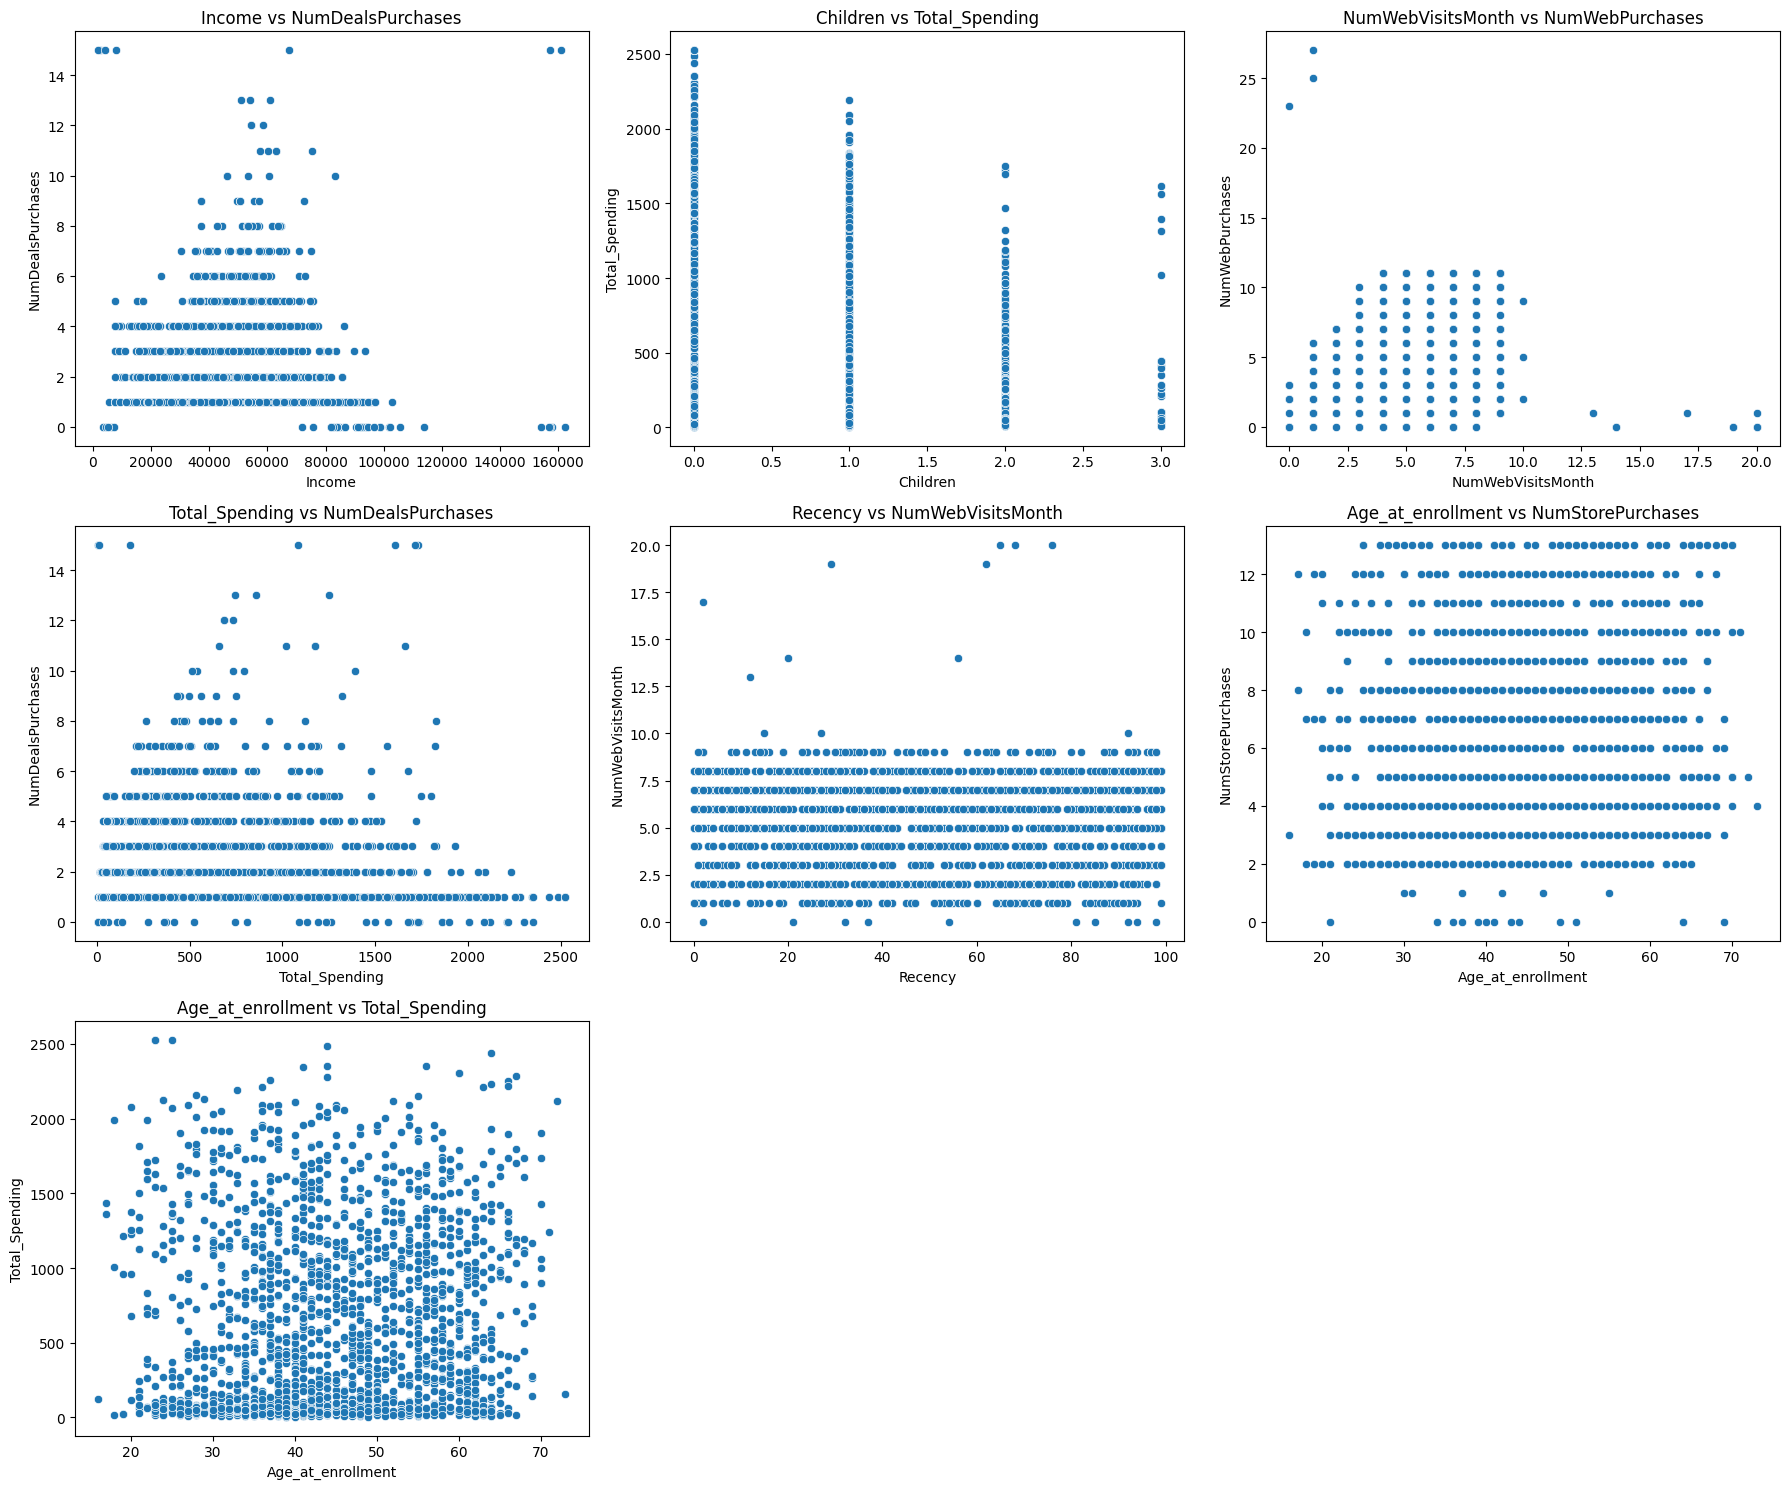

In [26]:
pairs = [
    ("Income", "NumDealsPurchases"),              # Deal sensitivity by income
    ("Children", "Total_Spending"),               # Household composition effect
    ("NumWebVisitsMonth", "NumWebPurchases"),     # Web conversion ratio
    ("Total_Spending", "NumDealsPurchases"),      # Deal-seekers vs high-value customers
    ("Recency", "NumWebVisitsMonth"),             # Recency vs Web activity
    ("Age_at_enrollment", "NumStorePurchases"),   # Channel preference by age
    ("Age_at_enrollment", "Total_Spending")       # Total spending vs Age
]

plot_scatter_grid(dataset, pairs, cols=3)

We can see some obvious relations between some variables but in many others there is no clear correlation

In [27]:
purchase_location_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
dataset["Total_Purchases"] = dataset[purchase_location_cols].sum(axis=1)
dataset["Total_Purchases"].describe()

count    2212.000000
mean       12.566908
std         7.205427
min         0.000000
25%         6.000000
50%        12.000000
75%        18.250000
max        32.000000
Name: Total_Purchases, dtype: float64

In [28]:
for col in purchase_location_cols:
    dataset[col + "_ratio"] = dataset[col] / dataset["Total_Purchases"]
dataset = dataset[dataset["Total_Purchases"] > 0]

<Axes: xlabel='NumWebPurchases_ratio', ylabel='NumStorePurchases_ratio'>

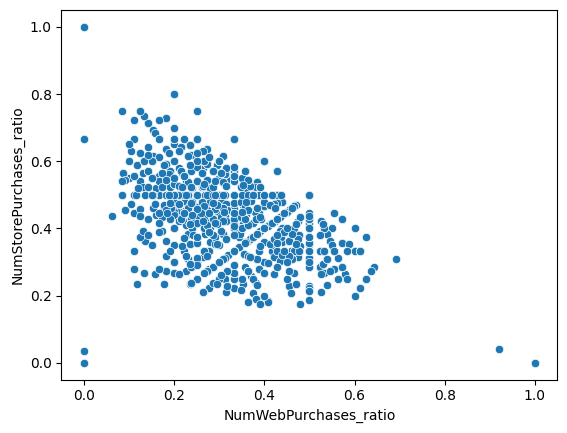

In [29]:
sns.scatterplot(
    data=dataset,
    x="NumWebPurchases_ratio",
    y="NumStorePurchases_ratio"
)

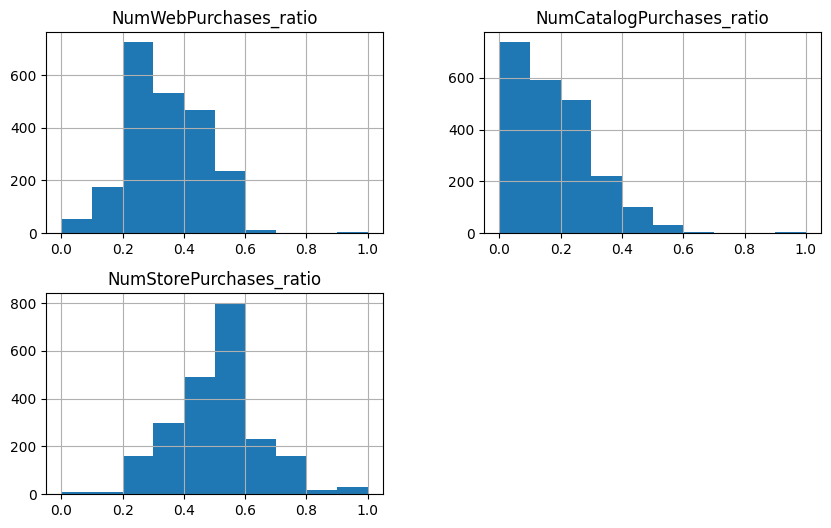

In [30]:
dataset[[col + "_ratio" for col in purchase_location_cols]].hist(figsize=(10,6))
plt.show()

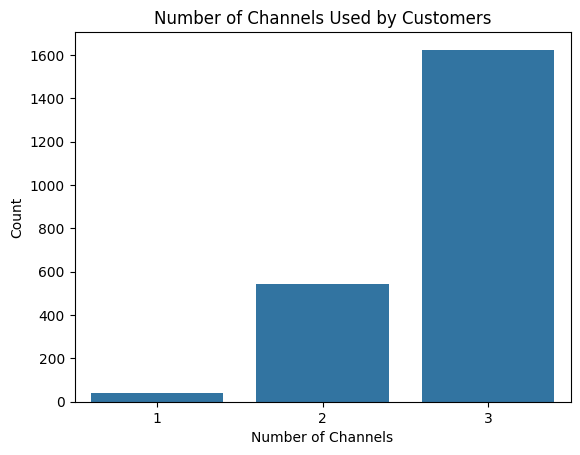

In [31]:
dataset["ChannelsUsed"] = (dataset[purchase_location_cols] > 0).sum(axis=1)
sns.countplot(x=dataset["ChannelsUsed"])
plt.title("Number of Channels Used by Customers")
plt.xlabel("Number of Channels")
plt.ylabel("Count")
plt.show()

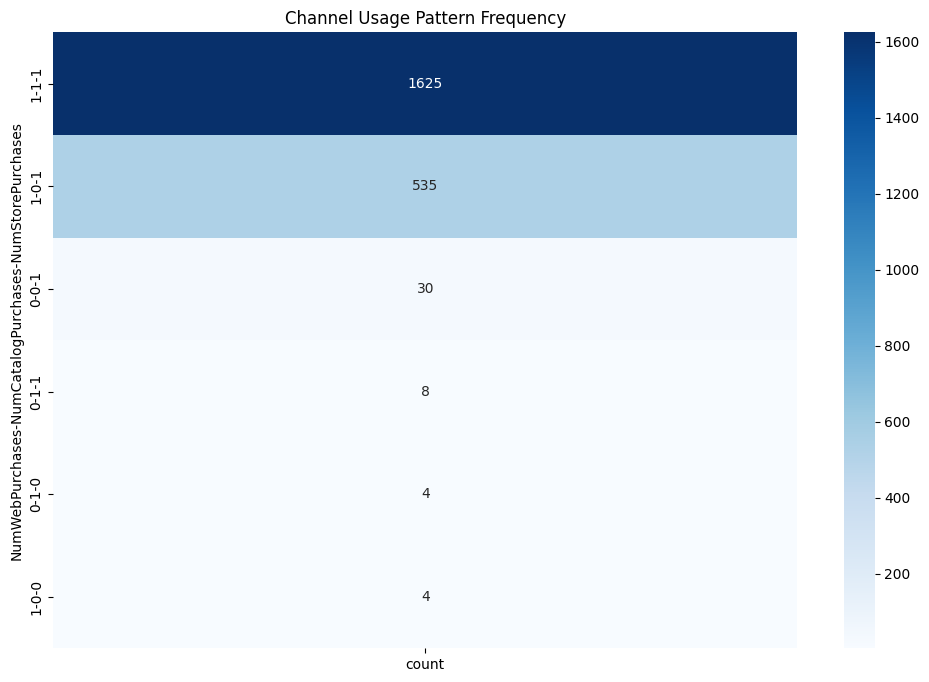

In [32]:
pattern = (dataset[purchase_location_cols] > 0).astype(int)

pattern_counts = pattern.value_counts().reset_index()
pattern_counts["count"] = pattern_counts.iloc[:, len(purchase_location_cols):].sum(axis=1)

heatmap_data = pattern_counts.set_index(purchase_location_cols)["count"].to_frame()

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues")
plt.title("Channel Usage Pattern Frequency")
plt.show()

In [33]:
campaign_cols = [
    "AcceptedCmp1","AcceptedCmp2","AcceptedCmp3",
    "AcceptedCmp4","AcceptedCmp5"
]

dataset["TotalAcceptedCmp"] = dataset[campaign_cols].sum(axis=1)
dataset[campaign_cols + ["Response"]].mean()

AcceptedCmp1    0.064370
AcceptedCmp2    0.013599
AcceptedCmp3    0.073889
AcceptedCmp4    0.074343
AcceptedCmp5    0.072983
Response        0.150952
dtype: float64

<Axes: xlabel='Response', ylabel='Income'>

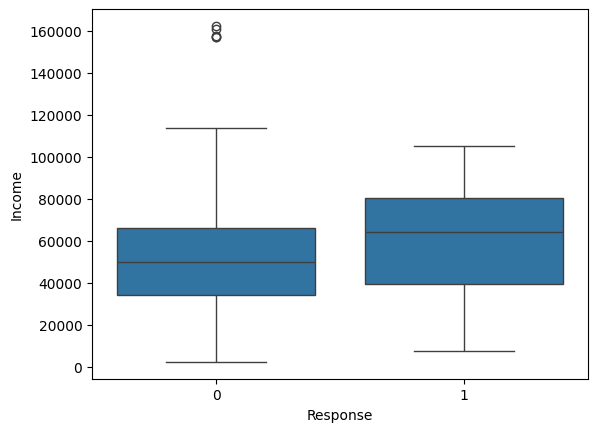

In [34]:
sns.boxplot(x="Response", y="Income", data=dataset)

<Axes: xlabel='Response', ylabel='Total_Spending'>

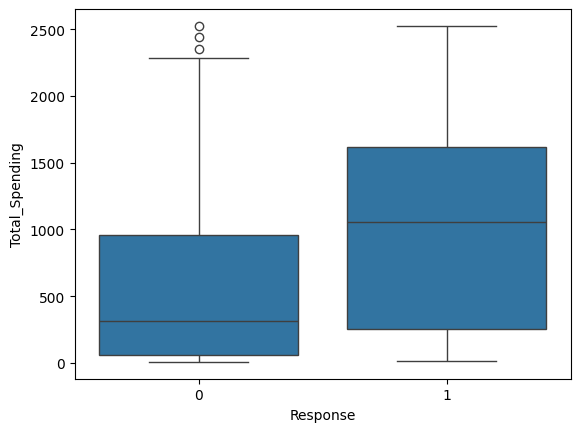

In [35]:
sns.boxplot(x="Response", y="Total_Spending", data=dataset)

In [36]:
dataset["Income_bin"] = pd.qcut(dataset["Income"], 4)

pd.crosstab(dataset["Income_bin"], dataset["Response"], normalize="index")

Response,0,1
Income_bin,,
"(2446.999, 35352.0]",0.894928,0.105072
"(35352.0, 51381.5]",0.874773,0.125227
"(51381.5, 68480.75]",0.896552,0.103448
"(68480.75, 162397.0]",0.730072,0.269928


<Axes: xlabel='Income_bin'>

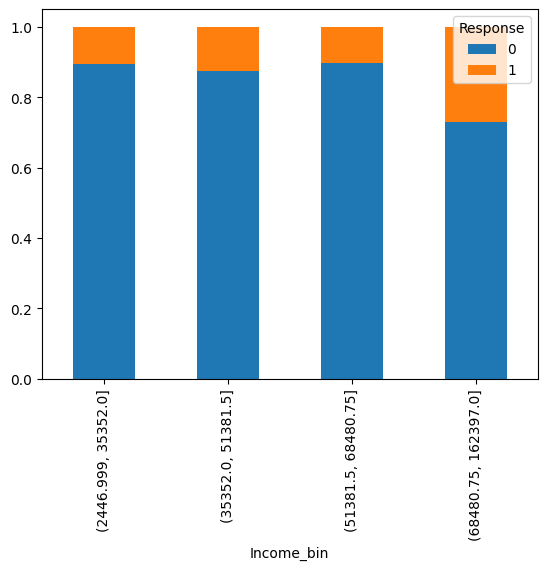

In [37]:
ct = pd.crosstab(
    dataset["Income_bin"],
    dataset["Response"],
    normalize="index"
)
ct.plot(kind="bar", stacked=True)

<Axes: >

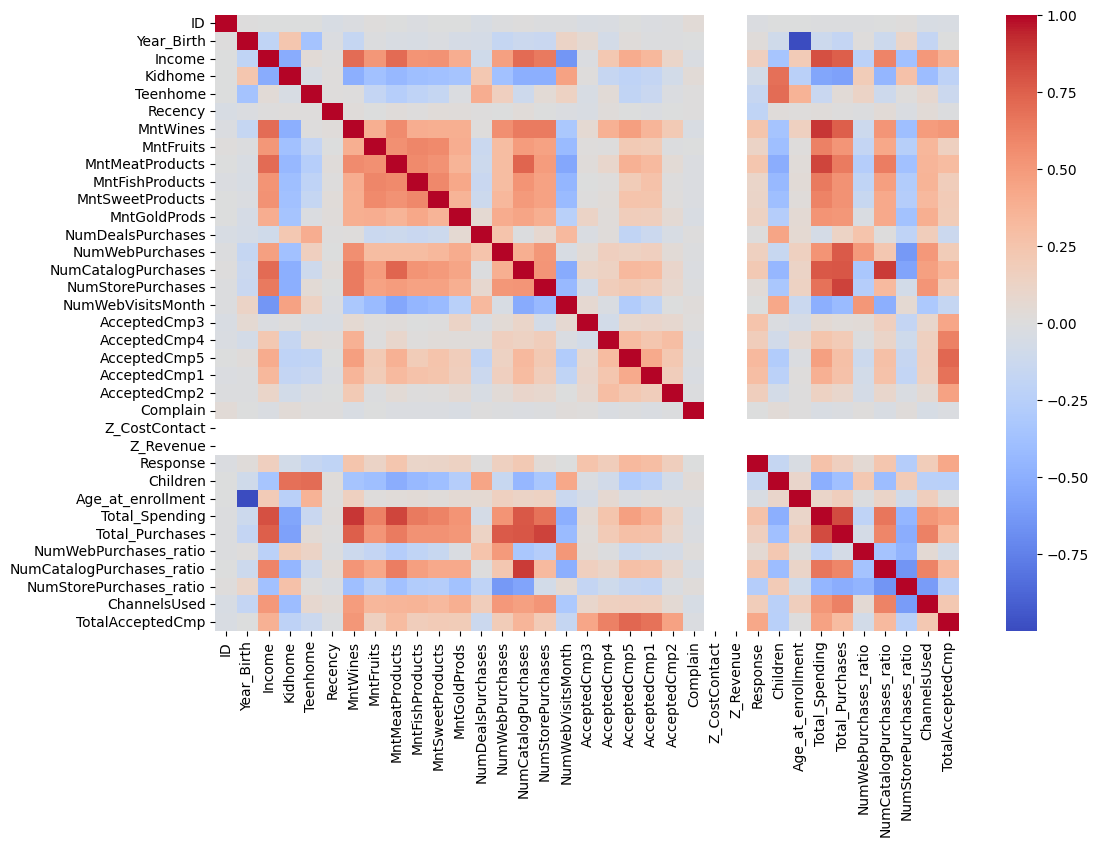

In [38]:
corr = dataset.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")

In [39]:
dataset["Education"].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [40]:
edu_map = {
    "Basic": 0,
    "2n Cycle": 1,
    "Graduation": 2,
    "Master": 3,
    "PhD": 4
}
dataset["Education_Ordinal"] = dataset["Education"].map(edu_map)
dataset["Is_Partnered"] = dataset["Marital_Status"].isin(["Married", "Together"]).astype(int)

<Axes: >

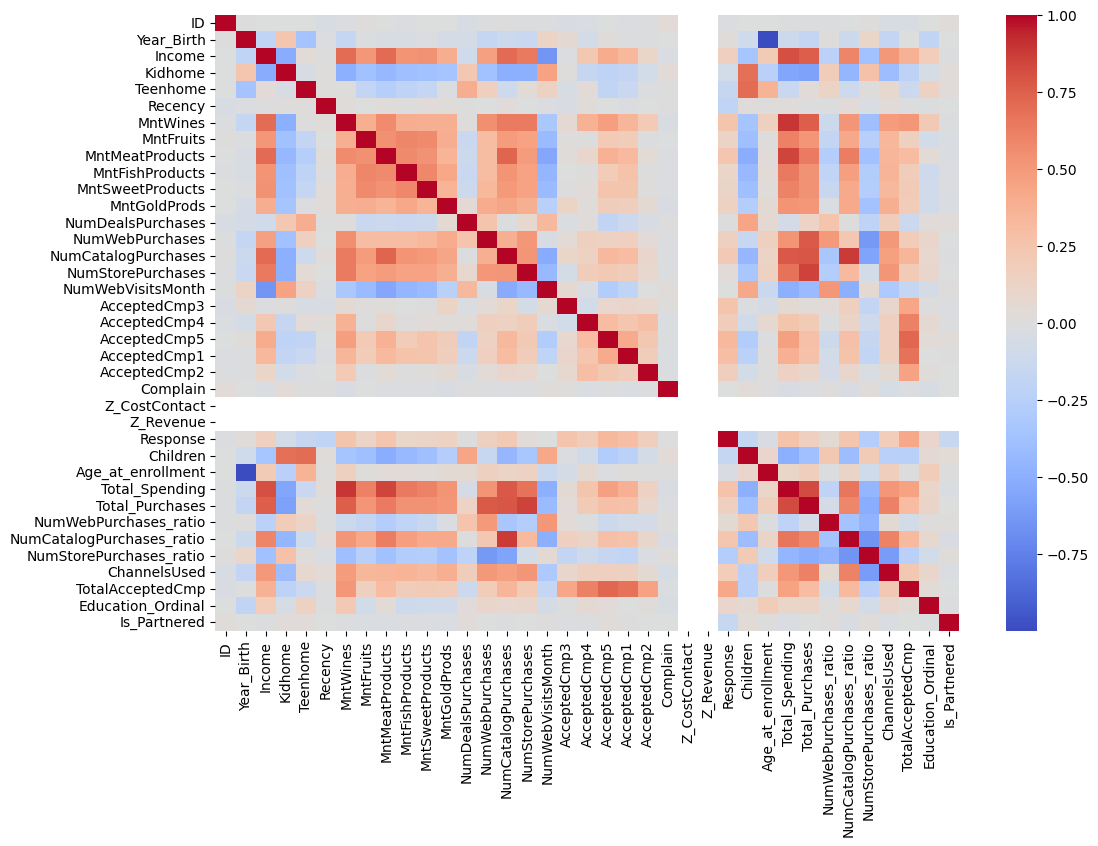

In [41]:
corr = dataset.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")

In [42]:
campaign_cols = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]
results = []

for cmp in campaign_cols:
    accepted = dataset[dataset[cmp] == 1]
    rejected = dataset[dataset[cmp] == 0]
    
    u_stat, p_income    = mannwhitneyu(accepted["Income"], rejected["Income"], alternative="two-sided")
    u_stat, p_spending  = mannwhitneyu(accepted["Total_Spending"], rejected["Total_Spending"], alternative="two-sided")
    u_stat, p_age       = mannwhitneyu(accepted["Age_at_enrollment"], rejected["Age_at_enrollment"], alternative="two-sided")
    
    results.append({
        "Campaign": cmp,
        "Accept_Rate": dataset[cmp].mean().round(3),
        "Median_Income_Accepted": accepted["Income"].median(),
        "Median_Income_Rejected": rejected["Income"].median(),
        "p_Income": round(p_income, 4),
        "Median_Spend_Accepted": accepted["Total_Spending"].median(),
        "p_Spending": round(p_spending, 4),
        "p_Age": round(p_age, 4),
    })

pd.DataFrame(results)

,Campaign,Accept_Rate,Median_Income_Accepted,Median_Income_Rejected,p_Income,Median_Spend_Accepted,p_Spending,p_Age
0,AcceptedCmp1,0.064,79967.0,49453.5,0.0000,1513.5,0.0000,0.5968
1,AcceptedCmp2,0.014,70896.5,51117.5,0.0000,1375.0,0.0000,0.5451
2,AcceptedCmp3,0.074,46998.0,51651.0,0.4841,488.0,0.0899,0.0031
3,AcceptedCmp4,0.074,67375.0,49509.5,0.0000,1169.5,0.0000,0.0007
4,AcceptedCmp5,0.073,82427.0,48985.0,0.0000,1658.0,0.0000,0.3622
5,Response,0.151,64090.0,50150.0,0.0000,1053.0,0.0000,0.1397


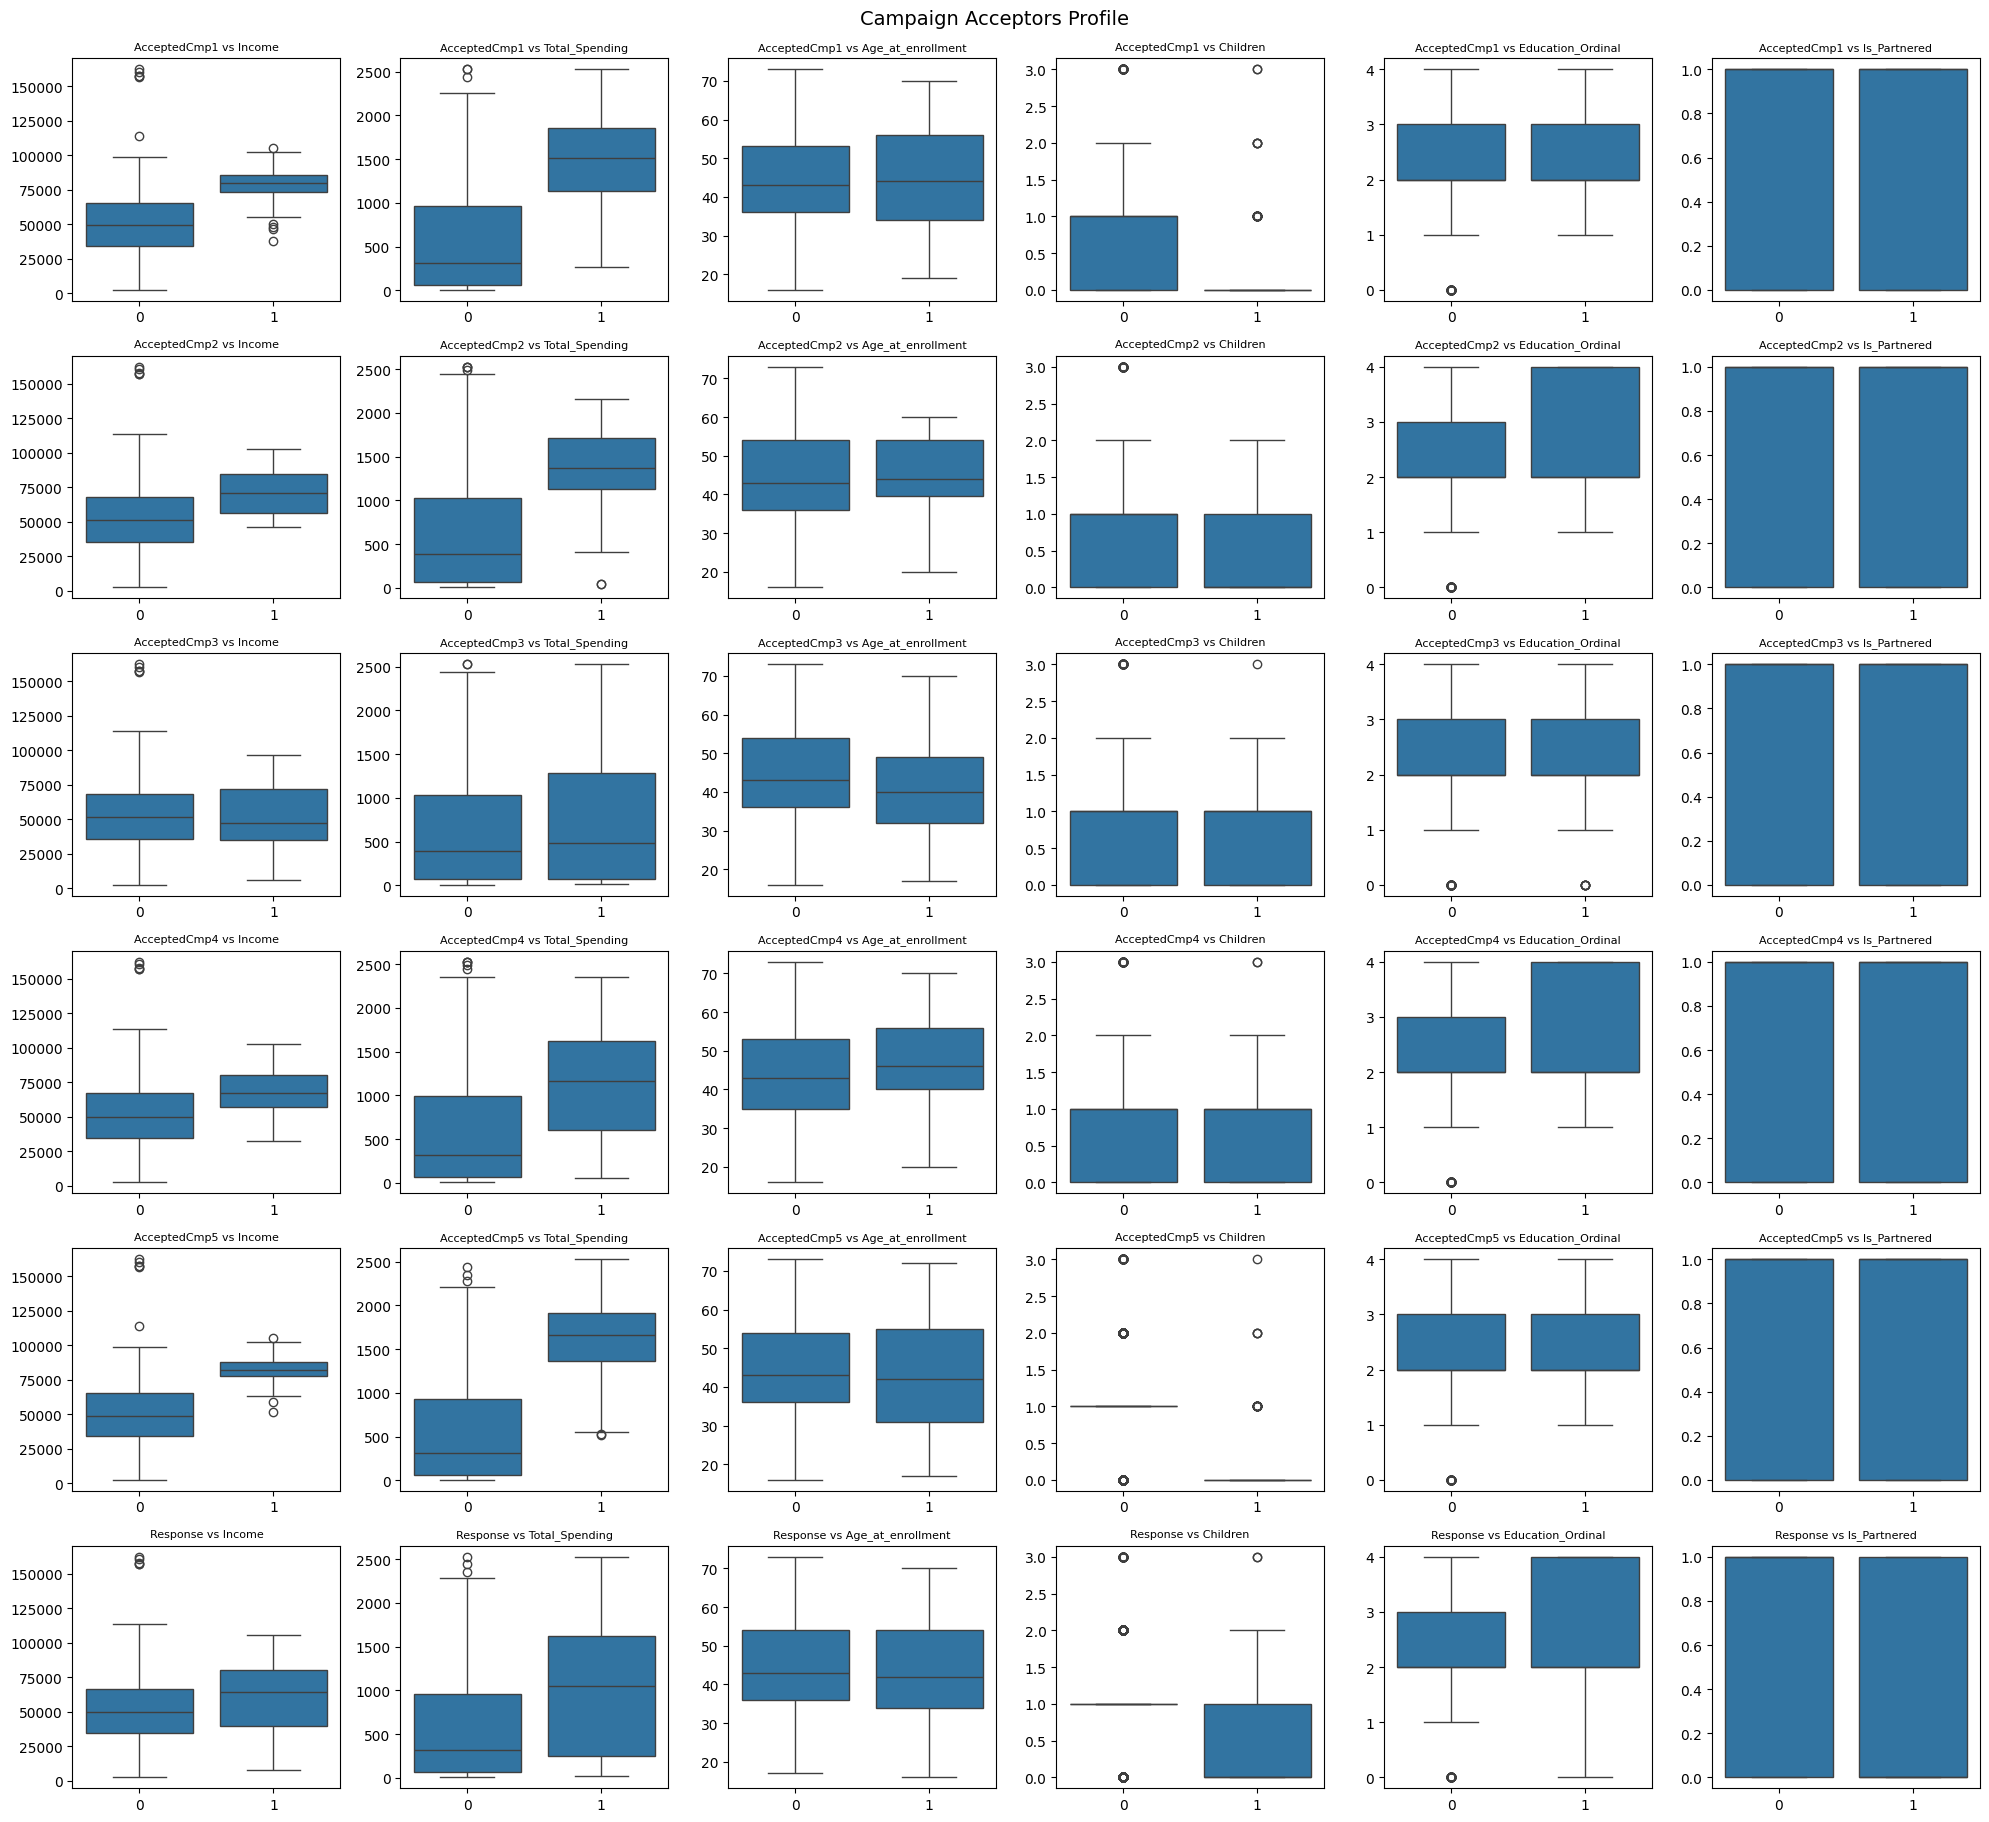

In [43]:
profile_vars = ["Income", "Total_Spending", "Age_at_enrollment", "Children", "Education_Ordinal", "Is_Partnered"]

fig, axes = plt.subplots(len(campaign_cols), len(profile_vars), figsize=(20, 18))

for i, cmp in enumerate(campaign_cols):
    for j, var in enumerate(profile_vars):
        ax = axes[i][j]
        sns.boxplot(x=dataset[cmp], y=dataset[var], ax=ax)
        ax.set_title(f"{cmp} vs {var}", fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("")

plt.tight_layout()
plt.suptitle("Campaign Acceptors Profile", y=1.01, fontsize=14)
plt.show()

In [44]:
cluster_features = [
    "Income", "Age_at_enrollment", "Children",
    "Total_Spending", "Total_Purchases", "Recency",
    "NumWebPurchases", "NumStorePurchases", "NumCatalogPurchases",
    "TotalAcceptedCmp", "ChannelsUsed",
    "Education_Ordinal", "Is_Partnered"
]

X = dataset[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features, index=dataset.index)

print(X_scaled_df.shape)
X_scaled_df.head()

(2206, 13)


,Income,Age_at_enrollment,Children,Total_Spending,Total_Purchases,Recency,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,TotalAcceptedCmp,ChannelsUsed,Education_Ordinal,Is_Partnered
0,0.291407,0.927924,-1.266906,1.673525,1.308371,0.310912,1.425194,-0.562359,2.500566,-0.439872,0.577218,-0.458244,-1.352111
1,-0.264252,1.353762,1.403705,-0.966002,-1.197311,-0.380038,-1.132371,-1.179554,-0.573695,-0.439872,0.577218,-0.458244,-1.352111
2,0.926264,0.331752,-1.266906,0.277398,1.029962,-0.794608,1.425194,1.289228,-0.232110,-0.439872,0.577218,-0.458244,0.739584
3,-1.192298,-1.201263,0.068400,-0.922840,-0.918902,-0.794608,-0.767004,-0.562359,-0.915279,-0.439872,-1.479879,-0.458244,0.739584
4,0.298709,-0.945761,0.068400,-0.310270,0.194735,1.554622,0.329095,0.054837,0.109474,-0.439872,0.577218,1.533651,0.739584


Rows dropped due to NaN: 0
Retained components: 9
Explained variance ratio: [0.403 0.102 0.078 0.077 0.074 0.061 0.058 0.043 0.039]


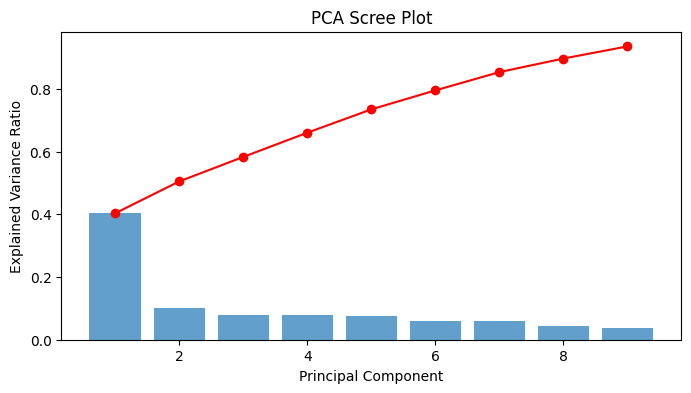

In [45]:
X_clean = X_scaled_df.dropna()
valid_idx = X_clean.index
print(f"Rows dropped due to NaN: {len(X_scaled_df) - len(X_clean)}")

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_clean)

print(f"Retained components: {pca.n_components_}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)}")

plt.figure(figsize=(8,4))
plt.bar(range(1, pca.n_components_+1), pca.explained_variance_ratio_, alpha=0.7)
plt.plot(range(1, pca.n_components_+1), pca.explained_variance_ratio_.cumsum(), marker='o', color='red')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.show()

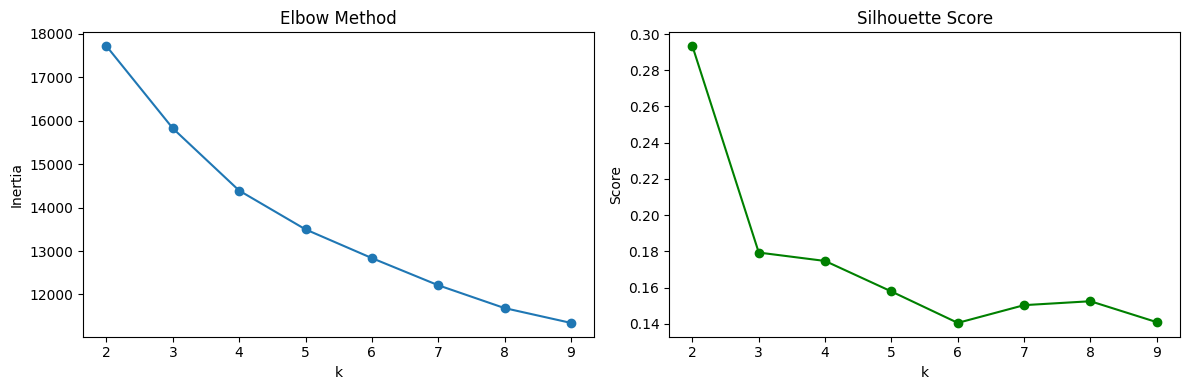

In [46]:
inertias, silhouettes = [], []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_range, inertias, marker='o')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(K_range, silhouettes, marker='o', color='green')
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [47]:
OPTIMAL_K = 3

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
dataset["Cluster"] = km_final.fit_predict(X_pca)

print(dataset["Cluster"].value_counts().sort_index())

Cluster
0    891
1    739
2    576
Name: count, dtype: int64


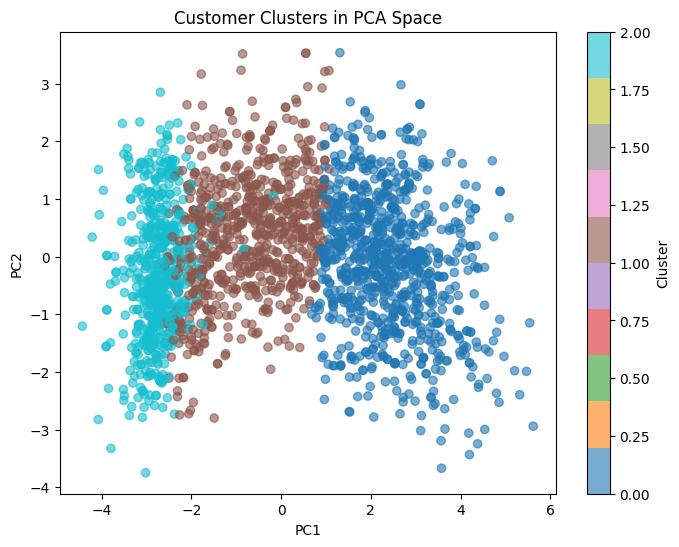

In [48]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dataset["Cluster"], cmap="tab10", alpha=0.6)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Clusters in PCA Space")
plt.show()

In [49]:
profile = dataset.groupby("Cluster")[cluster_features + campaign_cols].mean().round(2)
display(profile.T)
profile.info()

Cluster,0,1,2
Income,71520.58,43624.87,32368.60
Age_at_enrollment,46.06,44.60,40.44
Children,0.50,1.23,1.27
Total_Spending,1232.73,290.28,52.69
Total_Purchases,19.85,10.04,4.67
Recency,49.20,49.65,47.86
NumWebPurchases,5.84,3.88,1.68
NumStorePurchases,8.68,4.60,2.97
NumCatalogPurchases,5.33,1.56,0.02
TotalAcceptedCmp,0.59,0.14,0.04


<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 0 to 2
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Income               3 non-null      float64
 1   Age_at_enrollment    3 non-null      float64
 2   Children             3 non-null      float64
 3   Total_Spending       3 non-null      float64
 4   Total_Purchases      3 non-null      float64
 5   Recency              3 non-null      float64
 6   NumWebPurchases      3 non-null      float64
 7   NumStorePurchases    3 non-null      float64
 8   NumCatalogPurchases  3 non-null      float64
 9   TotalAcceptedCmp     3 non-null      float64
 10  ChannelsUsed         3 non-null      float64
 11  Education_Ordinal    3 non-null      float64
 12  Is_Partnered         3 non-null      float64
 13  AcceptedCmp1         3 non-null      float64
 14  AcceptedCmp2         3 non-null      float64
 15  AcceptedCmp3         3 non-null      float64
 16 

In [50]:
features = [
    "Income",
    "Age_at_enrollment",
    "Children",
    "Total_Spending",
    "Total_Purchases",
    "TotalAcceptedCmp",
    "Education_Ordinal",
    "Is_Partnered",
    "Response"
]

data = profile[features]

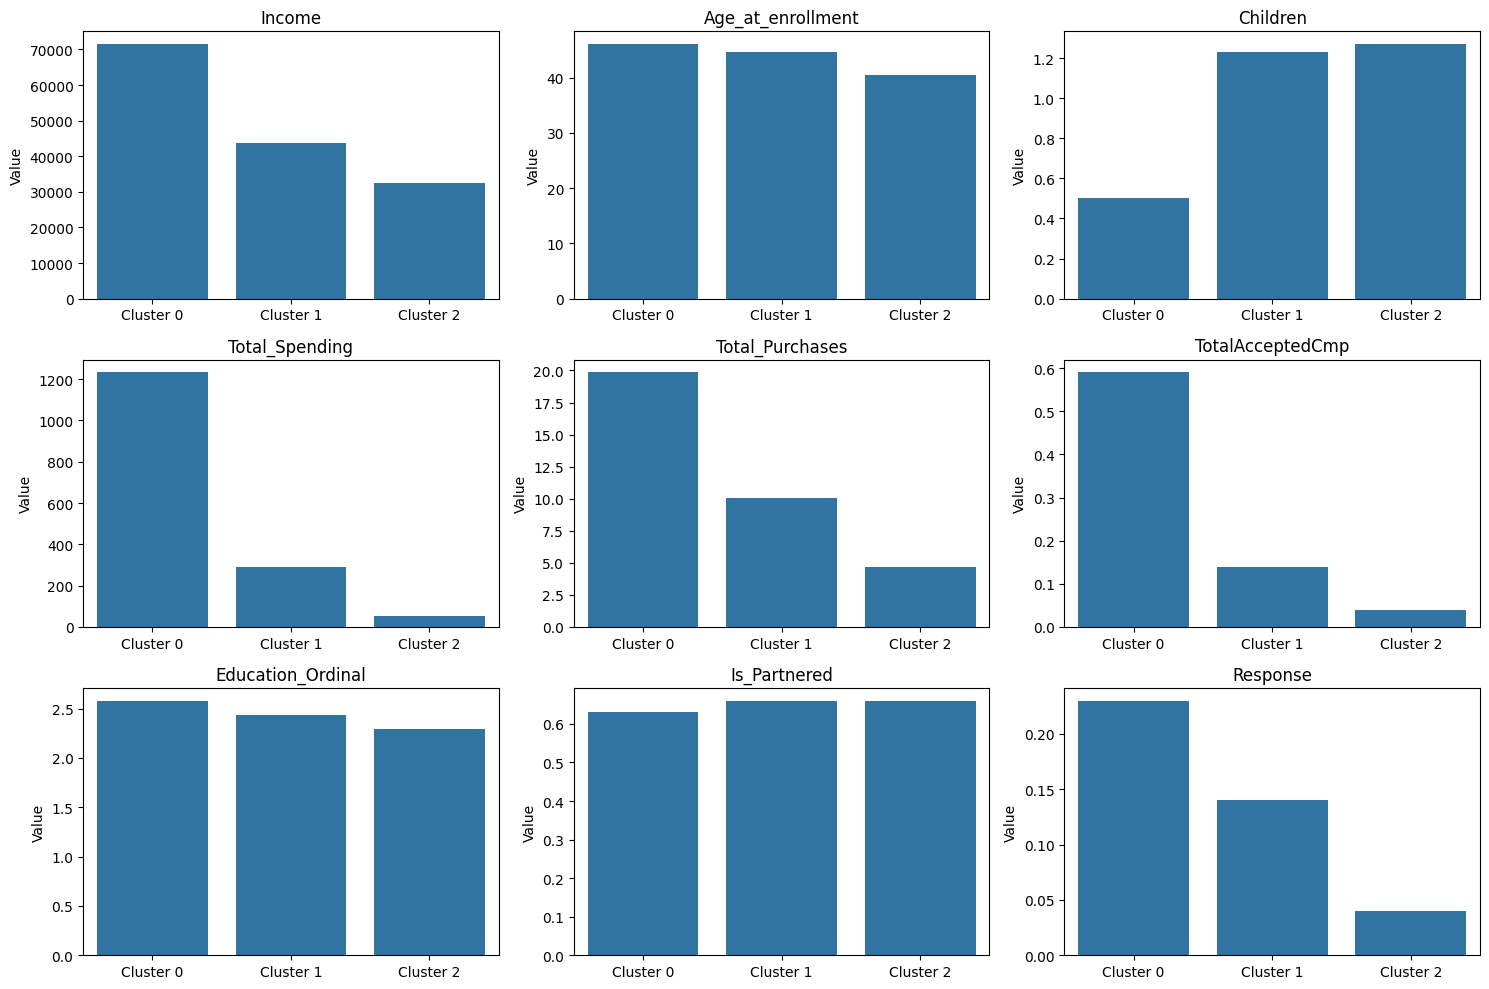

In [51]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.barplot(
        x=data.index,
        y=data[col],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value")
    axes[i].set_xticklabels([f"Cluster {int(x)}" for x in data.index])

plt.tight_layout()
plt.show()

In [52]:
scaler = StandardScaler()
data_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=features,
    index=data.index
)

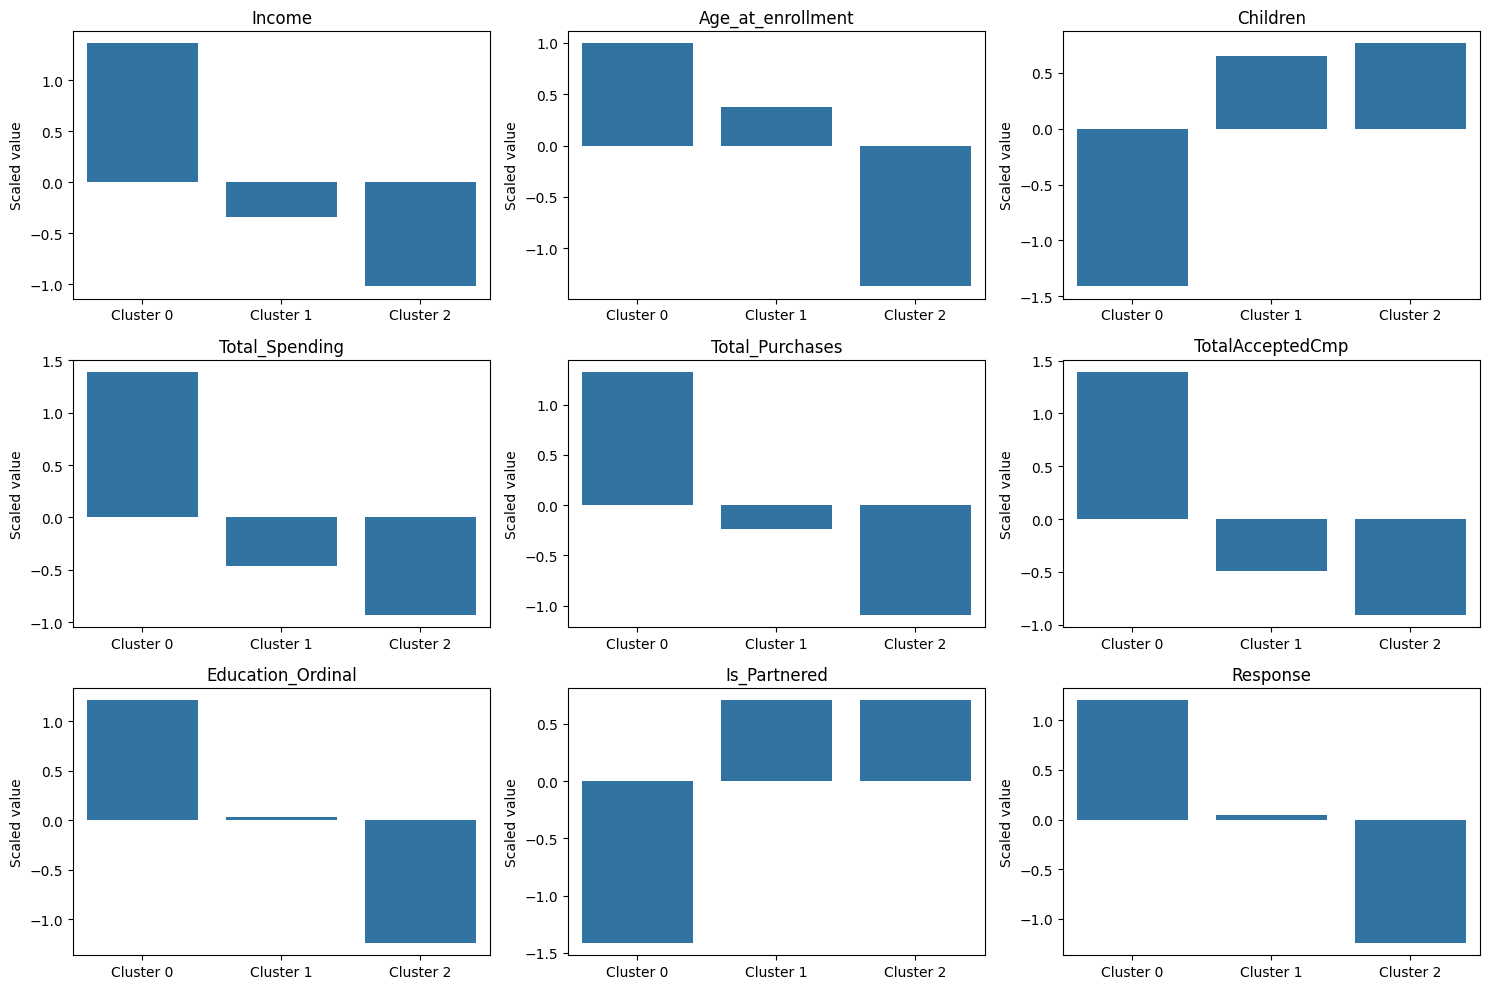

In [53]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.barplot(
        x=data_scaled.index,
        y=data_scaled[col],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Scaled value")
    axes[i].set_xticklabels([f"Cluster {int(x)}" for x in data_scaled.index])

plt.tight_layout()
plt.show()

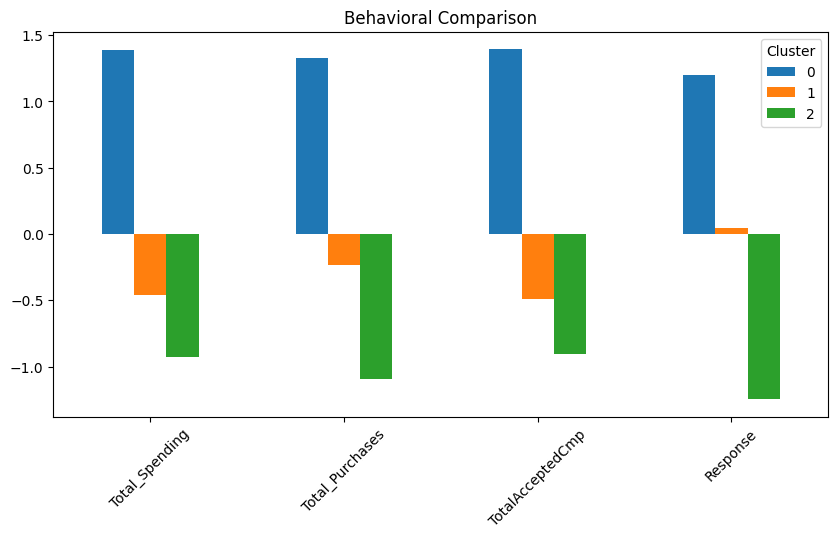

In [54]:
behavior = ["Total_Spending", "Total_Purchases", "TotalAcceptedCmp", "Response"]

data_scaled[behavior].T.plot(kind="bar", figsize=(10,5))
plt.title("Behavioral Comparison")
plt.xticks(rotation=45)
plt.show()

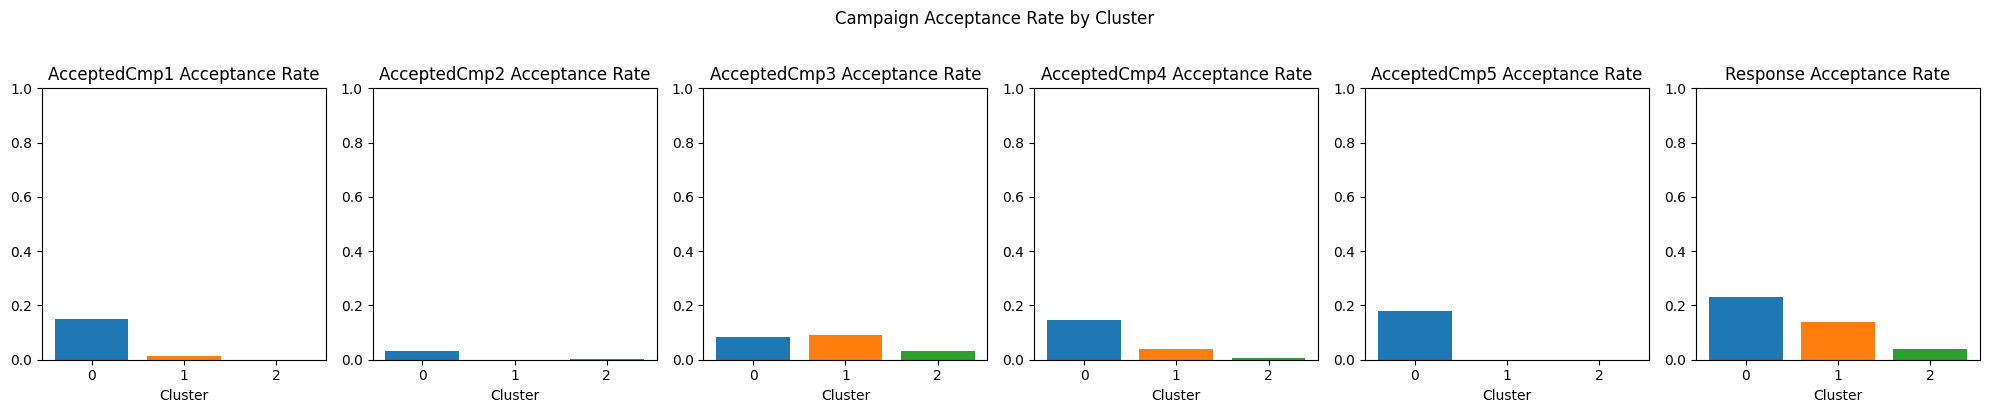

In [55]:
fig, axes = plt.subplots(1, len(campaign_cols), figsize=(20, 4))

for i, cmp in enumerate(campaign_cols):
    rates = dataset.groupby("Cluster")[cmp].mean()
    axes[i].bar(rates.index, rates.values, color=plt.cm.tab10.colors[:OPTIMAL_K])
    axes[i].set_title(f"{cmp} Acceptance Rate")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylim(0, 1)

plt.suptitle("Campaign Acceptance Rate by Cluster", y=1.02)
plt.tight_layout()
plt.show()

In [56]:
model_features = cluster_features + ["Cluster"]
target = "Response"

X_model = dataset[model_features]
y_model = dataset[target]

X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42, stratify=y_model)

gbc = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gbc.fit(X_train, y_train)

y_pred = gbc.predict(X_test)
y_proba = gbc.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.89      0.97      0.92       375
           1       0.62      0.30      0.40        67

    accuracy                           0.87       442
   macro avg       0.76      0.63      0.66       442
weighted avg       0.85      0.87      0.85       442

ROC-AUC: 0.8772


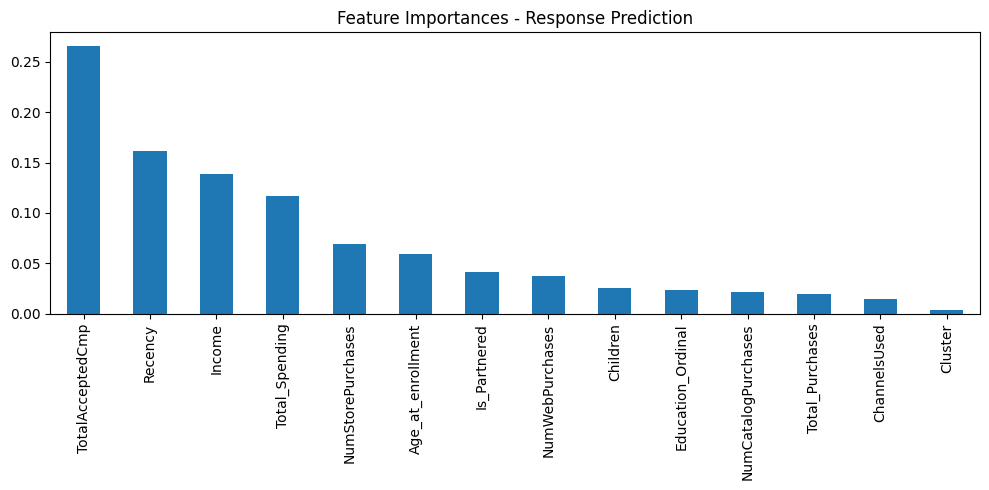

In [57]:
feat_imp = pd.Series(gbc.feature_importances_, index=model_features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
feat_imp.plot(kind="bar")
plt.title("Feature Importances - Response Prediction")
plt.tight_layout()
plt.show()

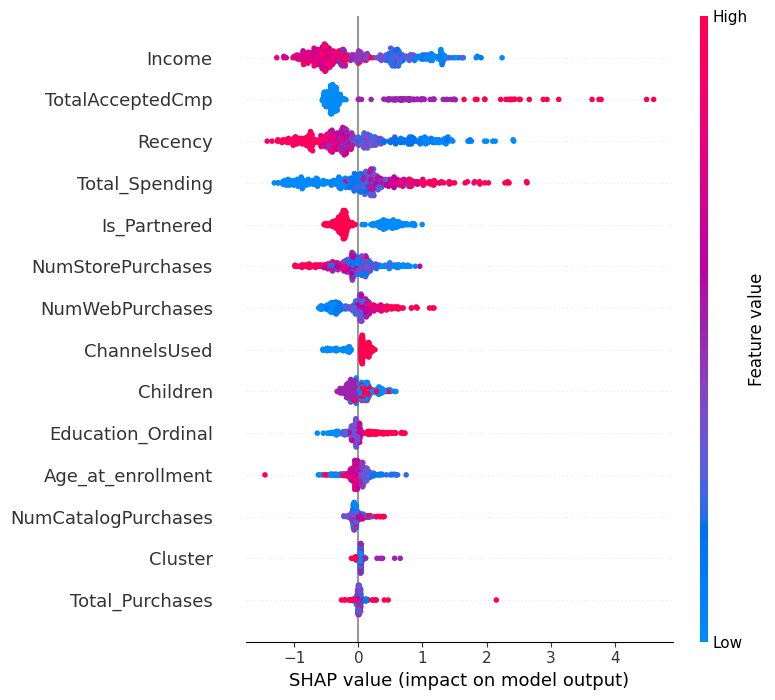

In [58]:
explainer = shap.TreeExplainer(gbc)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=model_features)

In [59]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Resampled class distribution:")
print(pd.Series(y_train_res).value_counts())

gbc_smote = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gbc_smote.fit(X_train_res, y_train_res)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=neg/pos,
    eval_metric="auc", random_state=42, verbosity=0
)
xgb.fit(X_train.to_numpy(), y_train.to_numpy())

xgb_proba = xgb.predict_proba(X_test.to_numpy())[:,1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

y_proba_smote = gbc_smote.predict_proba(X_test)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_smote)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
optimal_threshold = thresholds[f1_scores.argmax()]
print(f"\nOptimal threshold: {optimal_threshold:.3f}")

# Compare all three
for name, proba in [("GBM Original", y_proba),
                     ("GBM SMOTE", y_proba_smote),
                     ("XGBoost", xgb_proba)]:
    pred = (proba >= (optimal_threshold if "SMOTE" in name else 0.5)).astype(int)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, proba):.4f}")

Resampled class distribution:
Response
0    1498
1    1498
Name: count, dtype: int64

Optimal threshold: 0.549

--- GBM Original ---
              precision    recall  f1-score   support

           0       0.89      0.97      0.92       375
           1       0.62      0.30      0.40        67

    accuracy                           0.87       442
   macro avg       0.76      0.63      0.66       442
weighted avg       0.85      0.87      0.85       442

ROC-AUC: 0.8772

--- GBM SMOTE ---
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       375
           1       0.49      0.61      0.54        67

    accuracy                           0.84       442
   macro avg       0.71      0.75      0.72       442
weighted avg       0.86      0.84      0.85       442

ROC-AUC: 0.8636

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       375
           1       0.51      0.67   

In [60]:
spend_threshold = dataset["Total_Spending"].quantile(0.75)
dataset["Is_High_Spender"] = (dataset["Total_Spending"] >= spend_threshold).astype(int)
print(f"Spend threshold (75th percentile): {spend_threshold:.2f}")
print(dataset["Is_High_Spender"].value_counts())

hs_features = [f for f in model_features if f not in ["Total_Spending", "Is_High_Spender"]]

X_hs = dataset[hs_features]
y_hs = dataset["Is_High_Spender"]

X_hs_train, X_hs_test, y_hs_train, y_hs_test = train_test_split(
    X_hs, y_hs, test_size=0.2, random_state=42, stratify=y_hs
)

gbc_hs = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gbc_hs.fit(X_hs_train, y_hs_train)

y_hs_pred = gbc_hs.predict(X_hs_test)
y_hs_proba = gbc_hs.predict_proba(X_hs_test)[:,1]

print(classification_report(y_hs_test, y_hs_pred))
print(f"ROC-AUC: {roc_auc_score(y_hs_test, y_hs_proba):.4f}")

Spend threshold (75th percentile): 1048.75
Is_High_Spender
0    1654
1     552
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       331
           1       0.85      0.86      0.85       111

    accuracy                           0.93       442
   macro avg       0.90      0.90      0.90       442
weighted avg       0.93      0.93      0.93       442

ROC-AUC: 0.9721


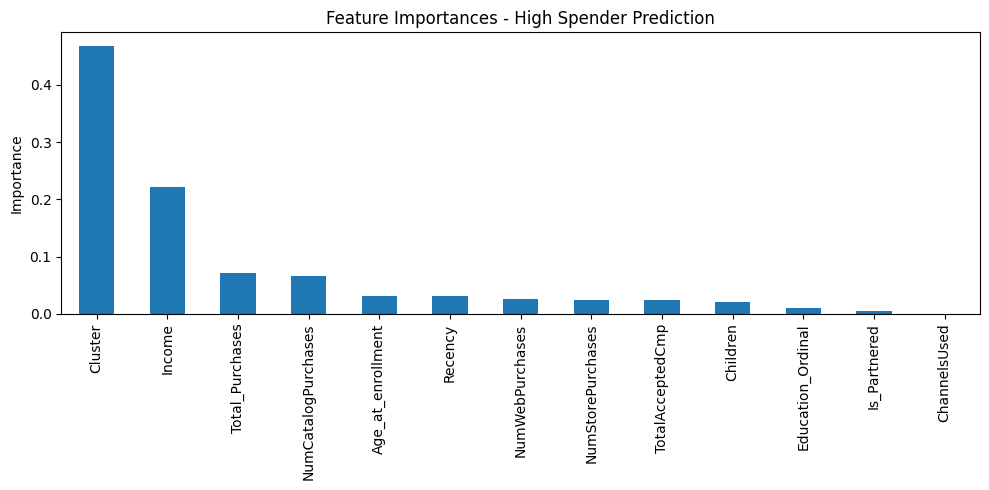


Top 5 drivers of high spending:
Cluster                0.468509
Income                 0.221748
Total_Purchases        0.070828
NumCatalogPurchases    0.065491
Age_at_enrollment      0.031680
dtype: float64


In [61]:
hs_feat_imp = pd.Series(gbc_hs.feature_importances_, index=hs_features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
hs_feat_imp.plot(kind="bar")
plt.title("Feature Importances - High Spender Prediction")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 5 drivers of high spending:")
print(hs_feat_imp.head())

In [62]:
product_cols = ["MntWines", "MntFruits", "MntMeatProducts", 
                "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

propensity_results = {}
propensity_models = {}

base_features = [f for f in model_features if f not in product_cols + ["Total_Spending", "Is_High_Spender"]]

for product in product_cols:
    threshold = dataset[product].median()
    y_prop = (dataset[product] > threshold).astype(int)
    
    if y_prop.mean() < 0.05 or y_prop.mean() > 0.95:
        print(f"Skipping {product} — insufficient variance (mean={y_prop.mean():.2f})")
        continue
    
    X_prop = dataset[base_features]
    
    X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
        X_prop, y_prop, test_size=0.2, random_state=42, stratify=y_prop
    )
    
    neg_p, pos_p = (y_p_train == 0).sum(), (y_p_train == 1).sum()
    
    xgb_prop = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        scale_pos_weight=neg_p/pos_p,
        eval_metric="auc", random_state=42, verbosity=0
    )
    xgb_prop.fit(X_p_train.to_numpy(), y_p_train.to_numpy())
    
    y_p_proba = xgb_prop.predict_proba(X_p_test.to_numpy())[:,1]
    auc = roc_auc_score(y_p_test, y_p_proba)
    
    propensity_models[product] = xgb_prop
    propensity_results[product] = {
        "AUC": round(auc, 4),
        "Positive_Rate": round(y_prop.mean(), 3),
        "Threshold": threshold
    }
    print(f"{product}: AUC={auc:.4f}, positive rate={y_prop.mean():.2f}")

pd.DataFrame(propensity_results).T

MntWines: AUC=0.9844, positive rate=0.50
MntFruits: AUC=0.9387, positive rate=0.49
MntMeatProducts: AUC=0.9838, positive rate=0.50
MntFishProducts: AUC=0.9233, positive rate=0.49
MntSweetProducts: AUC=0.9081, positive rate=0.50
MntGoldProds: AUC=0.9019, positive rate=0.49


,AUC,Positive_Rate,Threshold
MntWines,0.9844,0.500,177.5
MntFruits,0.9387,0.492,8.0
MntMeatProducts,0.9838,0.498,68.0
MntFishProducts,0.9233,0.493,12.0
MntSweetProducts,0.9081,0.497,8.0
MntGoldProds,0.9019,0.495,25.0


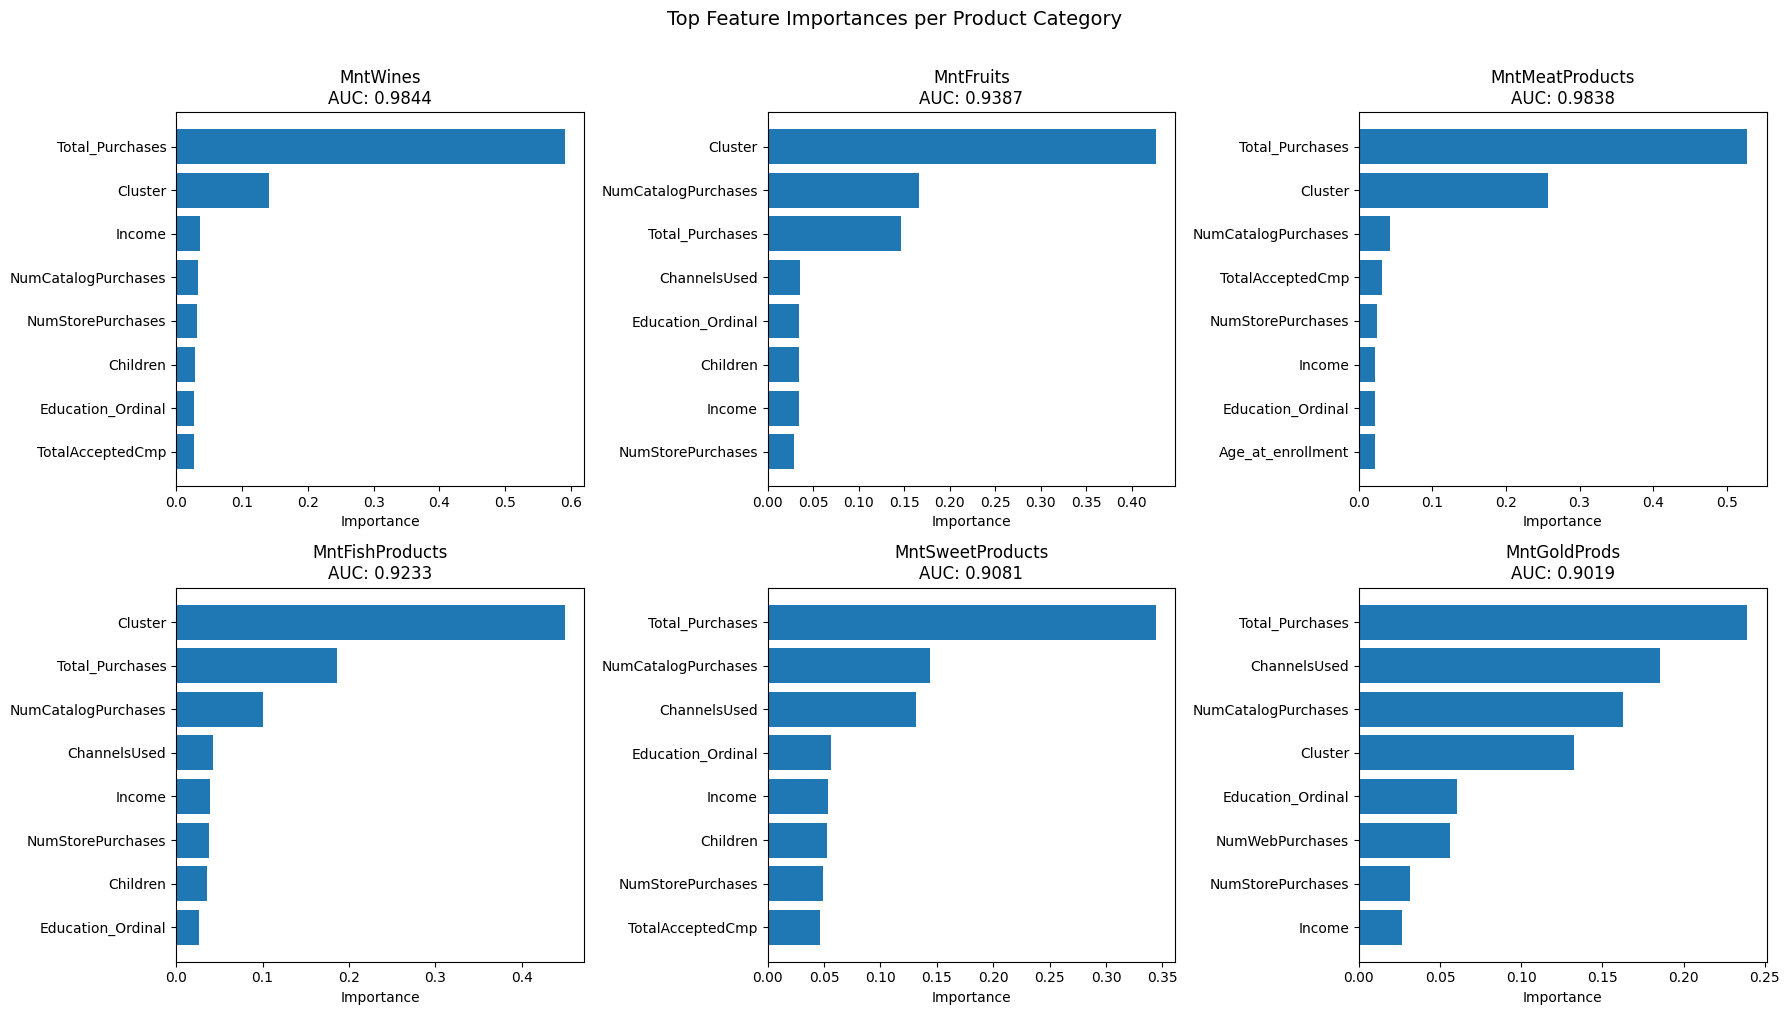

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (product, model) in enumerate(propensity_models.items()):
    imp = pd.Series(model.feature_importances_, index=base_features).sort_values(ascending=False).head(8)
    axes[i].barh(imp.index[::-1], imp.values[::-1])
    axes[i].set_title(f"{product}\nAUC: {propensity_results[product]['AUC']}")
    axes[i].set_xlabel("Importance")

plt.suptitle("Top Feature Importances per Product Category", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

         MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster                                                          
0           0.955      0.843            0.955            0.842   
1           0.340      0.387            0.335            0.395   
2           0.001      0.104            0.002            0.096   

         MntSweetProducts  MntGoldProds  
Cluster                                  
0                   0.834         0.796  
1                   0.402         0.482  
2                   0.094         0.061  


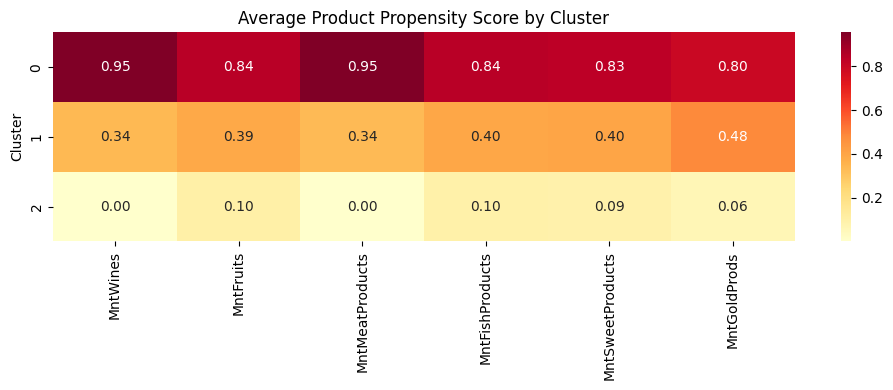

In [64]:
# Build propensity score matrix per customer
propensity_matrix = pd.DataFrame(index=dataset.index)

for product, model in propensity_models.items():
    X_prop = dataset[base_features].to_numpy()
    propensity_matrix[product] = model.predict_proba(X_prop)[:, 1]

# Mean propensity per cluster
propensity_by_cluster = propensity_matrix.copy()
propensity_by_cluster["Cluster"] = dataset["Cluster"].values

cluster_propensity = propensity_by_cluster.groupby("Cluster").mean().round(3)
print(cluster_propensity)

# Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(cluster_propensity, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Average Product Propensity Score by Cluster")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [65]:
share_features = [f for f in model_features if f not in spending_cols + ["Total_Spending", "Is_High_Spender"]]
share_results = {}

for product in spending_cols:
    y_share = dataset[product] / dataset["Total_Spending"]
    
    X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
        dataset[share_features], y_share, test_size=0.2, random_state=42
    )
    
    gbr = GradientBoostingRegressor(n_estimators=200, max_depth=3, 
                                     learning_rate=0.05, random_state=42)
    gbr.fit(X_s_train, y_s_train)
    r2 = r2_score(y_s_test, gbr.predict(X_s_test))
    share_results[product] = round(r2, 4)
    print(f"{product}: R²={r2:.4f}")

print("\nBest predicted categories:", sorted(share_results.items(), key=lambda x: -x[1]))

MntWines: R²=0.5314
MntFruits: R²=0.1824
MntMeatProducts: R²=0.3140
MntFishProducts: R²=0.2652
MntSweetProducts: R²=-0.4990
MntGoldProds: R²=0.5087

Best predicted categories: [('MntWines', 0.5314), ('MntGoldProds', 0.5087), ('MntMeatProducts', 0.314), ('MntFishProducts', 0.2652), ('MntFruits', 0.1824), ('MntSweetProducts', -0.499)]


In [66]:
print(dataset["MntSweetProducts"].describe())
print(f"Zero spenders: {(dataset['MntSweetProducts'] == 0).sum()} / {len(dataset)}")
print(f"Skewness: {stats.skew(dataset['MntSweetProducts']):.3f}")

count    2206.000000
mean       27.118314
std        41.123773
min         0.000000
25%         1.000000
50%         8.000000
75%        33.750000
max       262.000000
Name: MntSweetProducts, dtype: float64
Zero spenders: 410 / 2206
Skewness: 2.098


In [67]:
# Reframe as binary: does this customer buy sweets at all?
dataset["Buys_Sweets"] = (dataset["MntSweetProducts"] > 0).astype(int)
print(dataset["Buys_Sweets"].value_counts())

y_sw = dataset["Buys_Sweets"]
X_sw_train, X_sw_test, y_sw_train, y_sw_test = train_test_split(
    dataset[share_features], y_sw, test_size=0.2, random_state=42, stratify=y_sw
)

gbc_sw = GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                     learning_rate=0.05, random_state=42)
gbc_sw.fit(X_sw_train, y_sw_train)
auc = roc_auc_score(y_sw_test, gbc_sw.predict_proba(X_sw_test)[:,1])
print(f"Sweets buyer classification AUC: {auc:.4f}")

Buys_Sweets
1    1796
0     410
Name: count, dtype: int64
Sweets buyer classification AUC: 0.7698


count    2206.000000
mean        0.050689
std         0.060914
min         0.000000
25%         0.008632
50%         0.033196
75%         0.070291
max         0.945848
dtype: float64
Skewness of share: 3.296


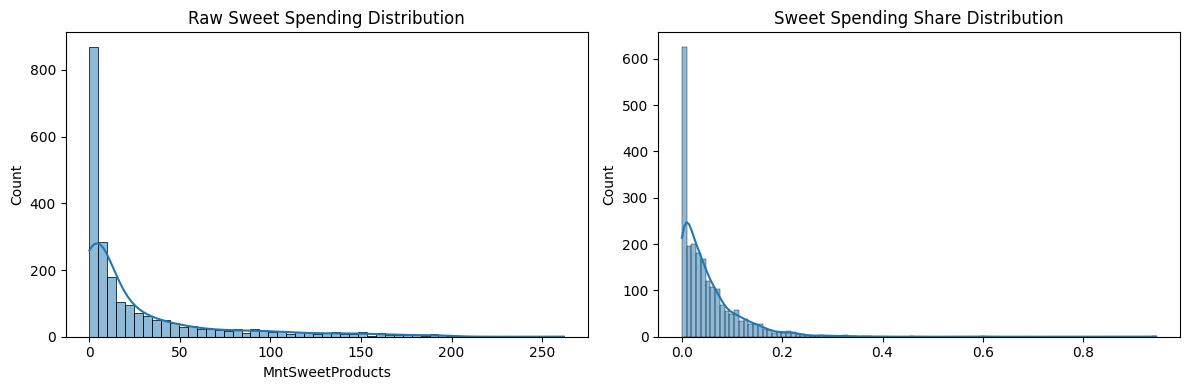

In [68]:
y_share_sweets = dataset["MntSweetProducts"] / dataset["Total_Spending"]

print(y_share_sweets.describe())
print(f"Skewness of share: {stats.skew(y_share_sweets):.3f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(dataset["MntSweetProducts"], kde=True)
plt.title("Raw Sweet Spending Distribution")

plt.subplot(1, 2, 2)
sns.histplot(y_share_sweets, kde=True)
plt.title("Sweet Spending Share Distribution")
plt.tight_layout()
plt.show()

In [69]:
y_share_sweets_log = np.log1p(dataset["MntSweetProducts"] / dataset["Total_Spending"])

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    dataset[share_features], y_share_sweets_log, test_size=0.2, random_state=42
)

gbr_sw = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                    learning_rate=0.05, random_state=42)
gbr_sw.fit(X_s_train, y_s_train)

y_sw_pred_log = gbr_sw.predict(X_s_test)
r2_log = r2_score(y_s_test, y_sw_pred_log)
print(f"R² on log-transformed share: {r2_log:.4f}")

# Back-transform for interpretability
y_sw_pred_actual = np.expm1(y_sw_pred_log)
y_s_test_actual = np.expm1(y_s_test)
r2_actual = r2_score(y_s_test_actual, y_sw_pred_actual)
print(f"R² back-transformed to original scale: {r2_actual:.4f}")

R² on log-transformed share: -0.0038
R² back-transformed to original scale: -0.0307


Channel distribution:
Preferred_Channel
Store      1459
Web         589
Catalog     158
Name: count, dtype: int64

               precision    recall  f1-score   support

     Catalog       0.94      0.94      0.94        32
       Store       0.99      0.99      0.99       292
         Web       0.99      0.98      0.99       118

    accuracy                           0.99       442
   macro avg       0.97      0.97      0.97       442
weighted avg       0.99      0.99      0.99       442



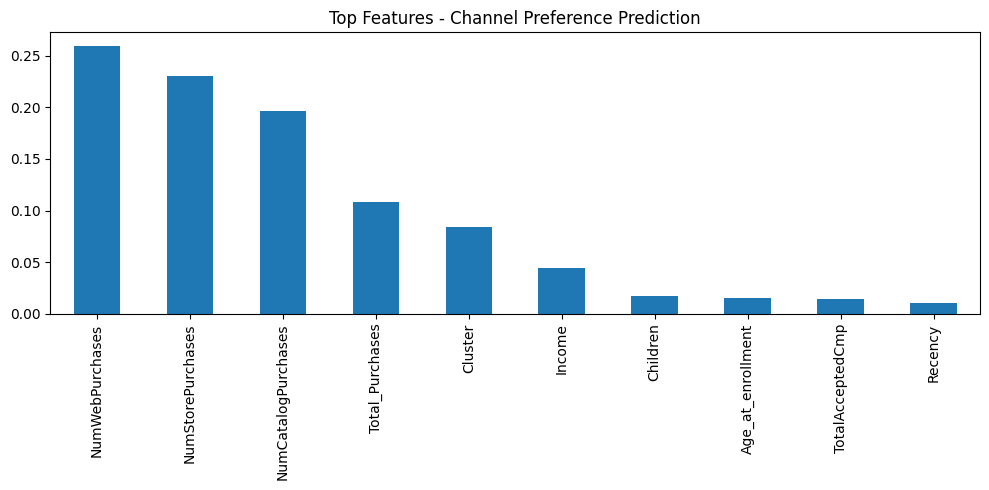

In [70]:
channel_map = {
    "NumWebPurchases": "Web",
    "NumCatalogPurchases": "Catalog",
    "NumStorePurchases": "Store"
}

dataset["Preferred_Channel"] = (
    dataset[["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]]
    .idxmax(axis=1)
    .map(channel_map)
)

print("Channel distribution:")
print(dataset["Preferred_Channel"].value_counts())

le = LabelEncoder()
y_channel = le.fit_transform(dataset["Preferred_Channel"])

channel_features = [f for f in model_features if f not in ["Total_Spending", "Is_High_Spender"]]
X_channel = dataset[channel_features]

X_ch_train, X_ch_test, y_ch_train, y_ch_test = train_test_split(
    X_channel, y_channel, test_size=0.2, random_state=42, stratify=y_channel
)

xgb_channel = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    objective="multi:softprob", num_class=len(le.classes_),
    eval_metric="mlogloss", random_state=42, verbosity=0
)
xgb_channel.fit(X_ch_train.to_numpy(), y_ch_train)

y_ch_pred = xgb_channel.predict(X_ch_test.to_numpy())
print("\n", classification_report(y_ch_test, y_ch_pred, target_names=le.classes_))

# Feature importance
ch_imp = pd.Series(xgb_channel.feature_importances_, index=channel_features).sort_values(ascending=False)
plt.figure(figsize=(10,5))
ch_imp.head(10).plot(kind="bar")
plt.title("Top Features - Channel Preference Prediction")
plt.tight_layout()
plt.show()

In [71]:
clv_features = [f for f in model_features if f not in ["Total_Spending", "Is_High_Spender"]]

X_clv = dataset[clv_features]
y_clv = dataset["Total_Spending"]

X_clv_train, X_clv_test, y_clv_train, y_clv_test = train_test_split(
    X_clv, y_clv, test_size=0.2, random_state=42
)

gbr_clv = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42
)
gbr_clv.fit(X_clv_train, y_clv_train)

y_clv_pred = gbr_clv.predict(X_clv_test)

mae = mean_absolute_error(y_clv_test, y_clv_pred)
r2 = r2_score(y_clv_test, y_clv_pred)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")

MAE: 110.16
R²: 0.8868


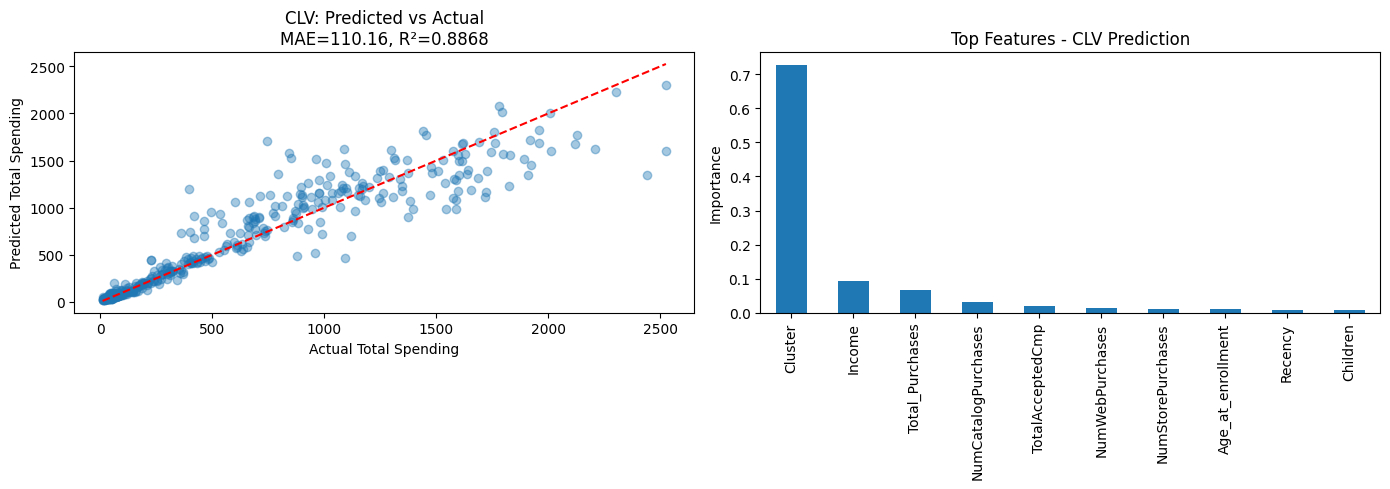

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_clv_test, y_clv_pred, alpha=0.4)
axes[0].plot([y_clv_test.min(), y_clv_test.max()],
             [y_clv_test.min(), y_clv_test.max()], 'r--')
axes[0].set_xlabel("Actual Total Spending")
axes[0].set_ylabel("Predicted Total Spending")
axes[0].set_title(f"CLV: Predicted vs Actual\nMAE={mae:.2f}, R²={r2:.4f}")

clv_imp = pd.Series(gbr_clv.feature_importances_, index=clv_features).sort_values(ascending=False)
clv_imp.head(10).plot(kind="bar", ax=axes[1])
axes[1].set_title("Top Features - CLV Prediction")
axes[1].set_ylabel("Importance")

plt.tight_layout()
plt.show()

Deal Sensitivity Segments:
                Income  Total_Spending  Deal_Sensitivity  TotalAcceptedCmp
Deal_Segment                                                              
Low           72018.93         1187.12              0.06              0.59
Medium        44347.74          372.10              0.24              0.17
High          37317.20          217.15              0.51              0.11


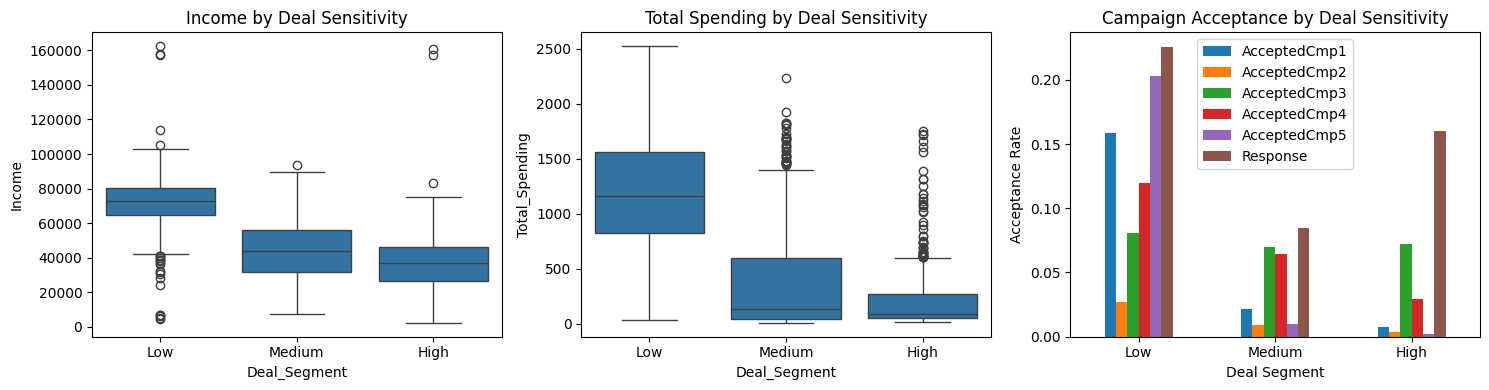

In [73]:
dataset["Deal_Sensitivity"] = (
    dataset["NumDealsPurchases"] / dataset["Total_Purchases"]
).fillna(0)

dataset["Deal_Segment"] = pd.qcut(
    dataset["Deal_Sensitivity"], 
    q=3, 
    labels=["Low", "Medium", "High"]
)

print("Deal Sensitivity Segments:")
print(dataset.groupby("Deal_Segment", observed=True)[
    ["Income", "Total_Spending", "Deal_Sensitivity", "TotalAcceptedCmp"]
].mean().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x="Deal_Segment", y="Income", data=dataset, ax=axes[0], order=["Low","Medium","High"])
axes[0].set_title("Income by Deal Sensitivity")

sns.boxplot(x="Deal_Segment", y="Total_Spending", data=dataset, ax=axes[1], order=["Low","Medium","High"])
axes[1].set_title("Total Spending by Deal Sensitivity")

deal_camp = dataset.groupby("Deal_Segment", observed=True)[campaign_cols].mean()
deal_camp.plot(kind="bar", ax=axes[2])
axes[2].set_title("Campaign Acceptance by Deal Sensitivity")
axes[2].set_xlabel("Deal Segment")
axes[2].set_ylabel("Acceptance Rate")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [74]:
recency_threshold = dataset["Recency"].quantile(0.75)
dataset["Churn_Risk"] = (dataset["Recency"] >= recency_threshold).astype(int)

print(f"Recency threshold (75th pct): {recency_threshold:.0f} days")
print(dataset["Churn_Risk"].value_counts())

churn_features = [f for f in model_features if f not in ["Is_High_Spender", "Total_Spending"]]
X_churn = dataset[churn_features]
y_churn = dataset["Churn_Risk"]

X_ch2_train, X_ch2_test, y_ch2_train, y_ch2_test = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

xgb_churn = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    eval_metric="auc", random_state=42, verbosity=0
)
xgb_churn.fit(X_ch2_train.to_numpy(), y_ch2_train)

y_churn_pred  = xgb_churn.predict(X_ch2_test.to_numpy())
y_churn_proba = xgb_churn.predict_proba(X_ch2_test.to_numpy())[:,1]

print(classification_report(y_ch2_test, y_churn_pred))
print(f"ROC-AUC: {roc_auc_score(y_ch2_test, y_churn_proba):.4f}")

Recency threshold (75th pct): 74 days
Churn_Risk
0    1642
1     564
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       329
           1       1.00      1.00      1.00       113

    accuracy                           1.00       442
   macro avg       1.00      1.00      1.00       442
weighted avg       1.00      1.00      1.00       442

ROC-AUC: 1.0000


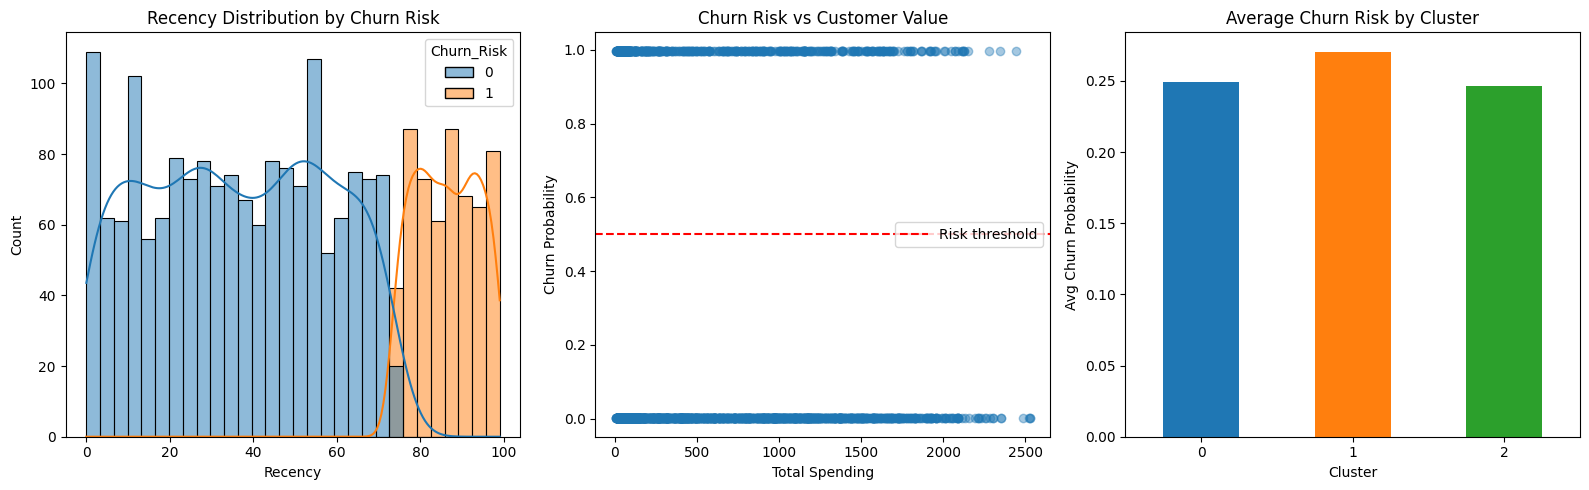


High-value customers at churn risk: 142
       Income  Total_Spending  Recency  Churn_Proba  Cluster Preferred_Channel
12    63033.0            1102       82       0.9978        0             Store
18    76995.0            1782       91       0.9978        0               Web
29    84618.0            1672       96       0.9978        0             Store
69    74854.0            1562       90       0.9978        1           Catalog
164  157243.0            1608       98       0.9978        0           Catalog
176   83837.0            1318       79       0.9978        0           Catalog
191   66973.0            1282       98       0.9978        0             Store
197   80067.0            1600       82       0.9978        0           Catalog
217   83790.0            1615       81       0.9978        0           Catalog
234   62745.0            1117       89       0.9978        0             Store


In [75]:
dataset["Churn_Proba"] = xgb_churn.predict_proba(X_churn.to_numpy())[:,1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(data=dataset, x="Recency", hue="Churn_Risk", 
             kde=True, ax=axes[0], bins=30)
axes[0].set_title("Recency Distribution by Churn Risk")

axes[1].scatter(dataset["Total_Spending"], dataset["Churn_Proba"], alpha=0.4)
axes[1].axhline(0.5, color='red', linestyle='--', label='Risk threshold')
axes[1].set_xlabel("Total Spending")
axes[1].set_ylabel("Churn Probability")
axes[1].set_title("Churn Risk vs Customer Value")
axes[1].legend()

churn_by_cluster = dataset.groupby("Cluster")["Churn_Proba"].mean()
churn_by_cluster.plot(kind="bar", ax=axes[2], color=plt.cm.tab10.colors)
axes[2].set_title("Average Churn Risk by Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Avg Churn Probability")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

high_value_at_risk = dataset[
    (dataset["Churn_Proba"] >= 0.5) & 
    (dataset["Total_Spending"] >= dataset["Total_Spending"].quantile(0.75))
].sort_values("Churn_Proba", ascending=False)

print(f"\nHigh-value customers at churn risk: {len(high_value_at_risk)}")
print(high_value_at_risk[["Income", "Total_Spending", "Recency", "Churn_Proba", "Cluster", "Preferred_Channel"]].head(10))

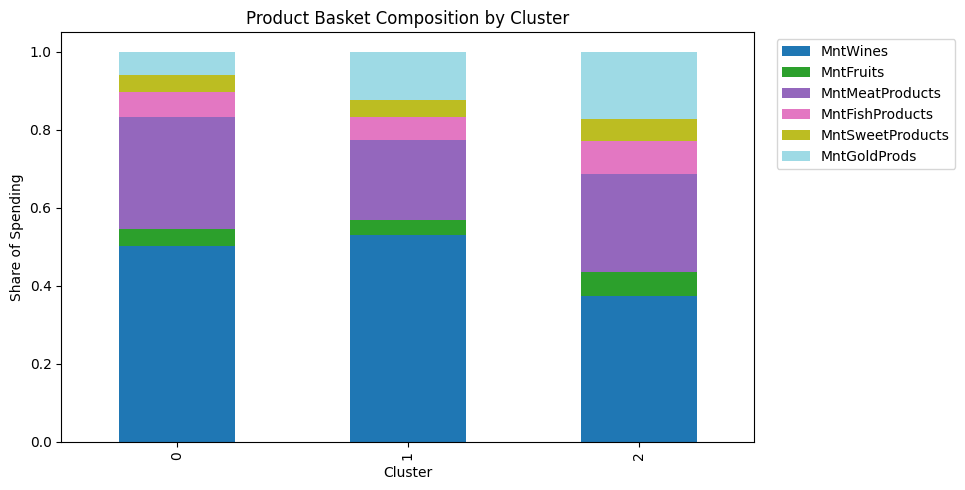

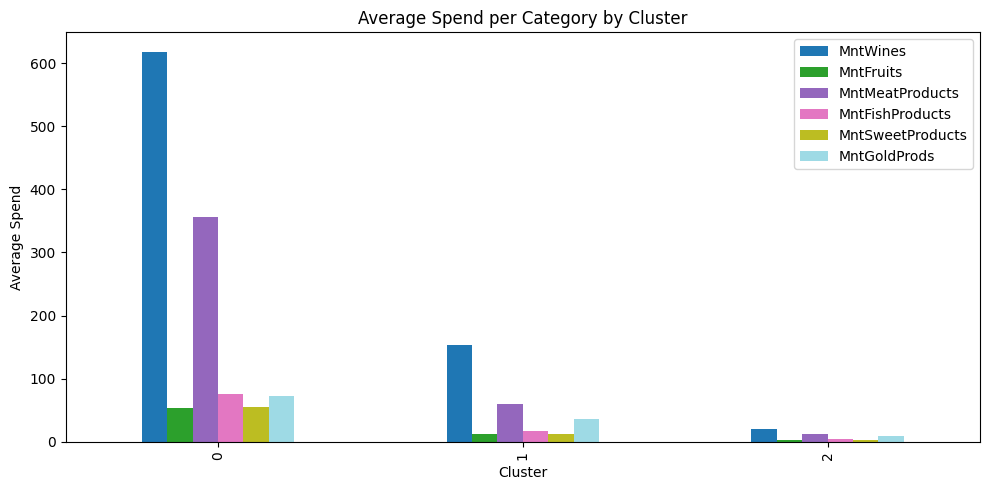

In [76]:
basket = dataset.groupby("Cluster")[spending_cols].mean()
basket_pct = basket.div(basket.sum(axis=1), axis=0)

basket_pct.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab20")
plt.title("Product Basket Composition by Cluster")
plt.ylabel("Share of Spending")
plt.xlabel("Cluster")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

basket.plot(kind="bar", figsize=(10, 5), colormap="tab20")
plt.title("Average Spend per Category by Cluster")
plt.ylabel("Average Spend")
plt.tight_layout()
plt.show()

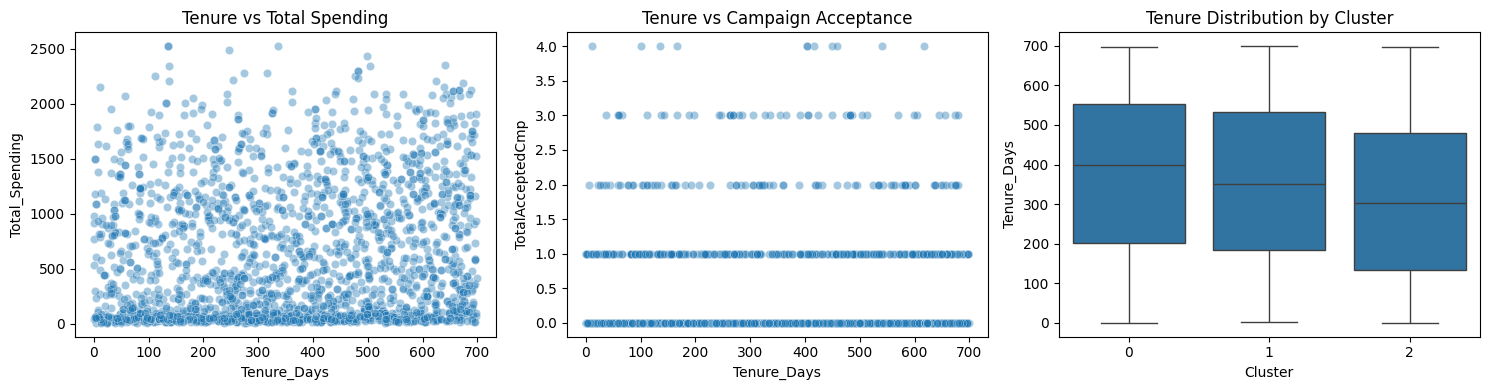

Income             -0.026033
TotalAcceptedCmp   -0.013378
Churn_Proba         0.008217
Recency             0.025449
Total_Spending      0.156447
Name: Tenure_Days, dtype: float64


In [77]:
reference_date = dataset["Dt_Customer"].max()
dataset["Tenure_Days"] = (reference_date - dataset["Dt_Customer"]).dt.days

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x=dataset["Tenure_Days"], y=dataset["Total_Spending"], ax=axes[0], alpha=0.4)
axes[0].set_title("Tenure vs Total Spending")

sns.scatterplot(x=dataset["Tenure_Days"], y=dataset["TotalAcceptedCmp"], ax=axes[1], alpha=0.4)
axes[1].set_title("Tenure vs Campaign Acceptance")

sns.boxplot(x=dataset["Cluster"], y=dataset["Tenure_Days"], ax=axes[2])
axes[2].set_title("Tenure Distribution by Cluster")

plt.tight_layout()
plt.show()

# Tenure correlation with key variables
tenure_corr = dataset[["Tenure_Days", "Total_Spending", "TotalAcceptedCmp", 
                         "Churn_Proba", "Income", "Recency"]].corr()["Tenure_Days"].drop("Tenure_Days")
print(tenure_corr.sort_values())

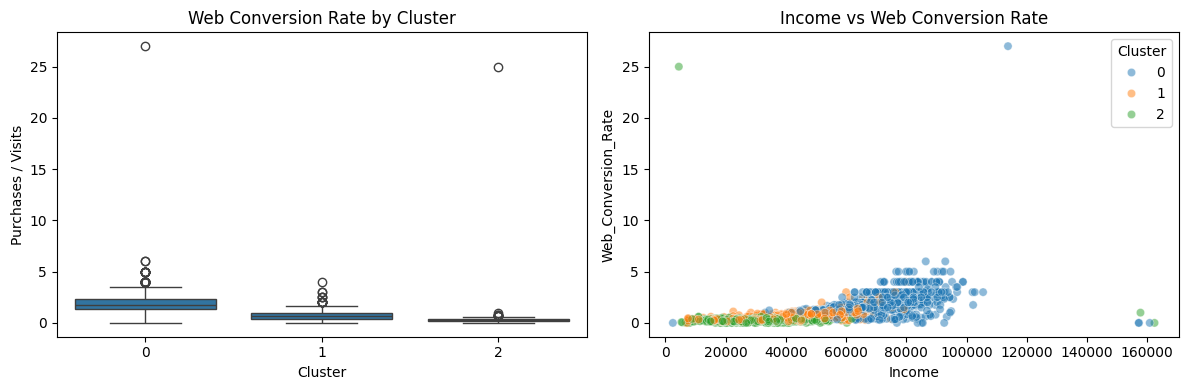

         count   mean    std  min    25%    50%    75%   max
Cluster                                                     
0        891.0  1.913  1.254  0.0  1.333  1.750  2.333  27.0
1        739.0  0.689  0.416  0.0  0.375  0.625  1.000   4.0
2        576.0  0.294  1.041  0.0  0.143  0.250  0.333  25.0


In [78]:
dataset["Web_Conversion_Rate"] = (
    dataset["NumWebPurchases"] / dataset["NumWebVisitsMonth"]
).replace([np.inf], np.nan).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=dataset["Cluster"], y=dataset["Web_Conversion_Rate"], ax=axes[0])
axes[0].set_title("Web Conversion Rate by Cluster")
axes[0].set_ylabel("Purchases / Visits")

sns.scatterplot(x=dataset["Income"], y=dataset["Web_Conversion_Rate"], 
                hue=dataset["Cluster"], ax=axes[1], alpha=0.5, palette="tab10")
axes[1].set_title("Income vs Web Conversion Rate")

plt.tight_layout()
plt.show()

print(dataset.groupby("Cluster")["Web_Conversion_Rate"].describe().round(3))

Dominant category distribution:
Dominant_Category
MntWines            1515
MntMeatProducts      435
MntGoldProds         166
MntFishProducts       59
MntSweetProducts      16
MntFruits             15
Name: count, dtype: int64
                  precision    recall  f1-score   support

 MntFishProducts       1.00      0.08      0.15        12
       MntFruits       0.00      0.00      0.00         3
    MntGoldProds       0.43      0.61      0.50        33
 MntMeatProducts       0.51      0.29      0.37        87
MntSweetProducts       0.00      0.00      0.00         3
        MntWines       0.82      0.93      0.88       304

        accuracy                           0.75       442
       macro avg       0.46      0.32      0.32       442
    weighted avg       0.73      0.75      0.72       442



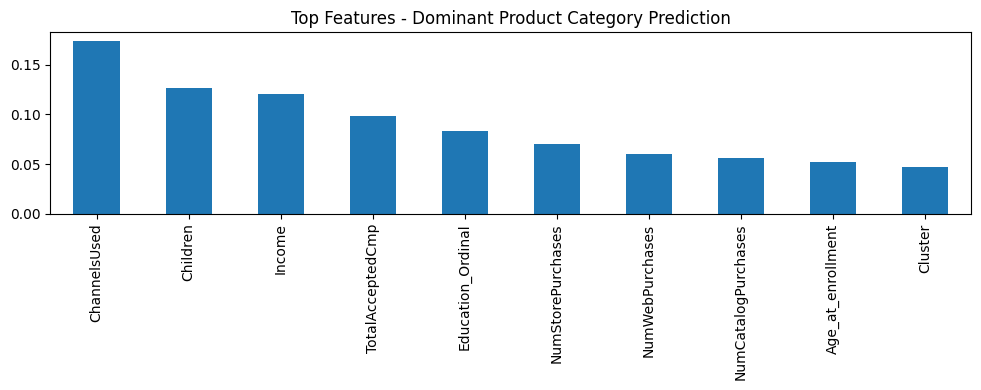

In [79]:
# Dominant category = where the customer spends the most
dataset["Dominant_Category"] = dataset[spending_cols].idxmax(axis=1)
print("Dominant category distribution:")
print(dataset["Dominant_Category"].value_counts())

le_cat = LabelEncoder()
y_cat = le_cat.fit_transform(dataset["Dominant_Category"])

cat_features = [f for f in model_features if f not in spending_cols + ["Total_Spending", "Is_High_Spender"]]
X_cat = dataset[cat_features]

X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

xgb_cat = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    objective="multi:softprob", num_class=len(le_cat.classes_),
    eval_metric="mlogloss", random_state=42, verbosity=0
)
xgb_cat.fit(X_cat_train.to_numpy(), y_cat_train)

y_cat_pred = xgb_cat.predict(X_cat_test.to_numpy())
print(classification_report(y_cat_test, y_cat_pred, target_names=le_cat.classes_))

# Feature importance
cat_imp = pd.Series(xgb_cat.feature_importances_, index=cat_features).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
cat_imp.head(10).plot(kind="bar")
plt.title("Top Features - Dominant Product Category Prediction")
plt.tight_layout()
plt.show()

RFM_Segment
Loyal             687
Potential         660
At Risk           358
Best Customers    330
Lost              171
Name: count, dtype: int64


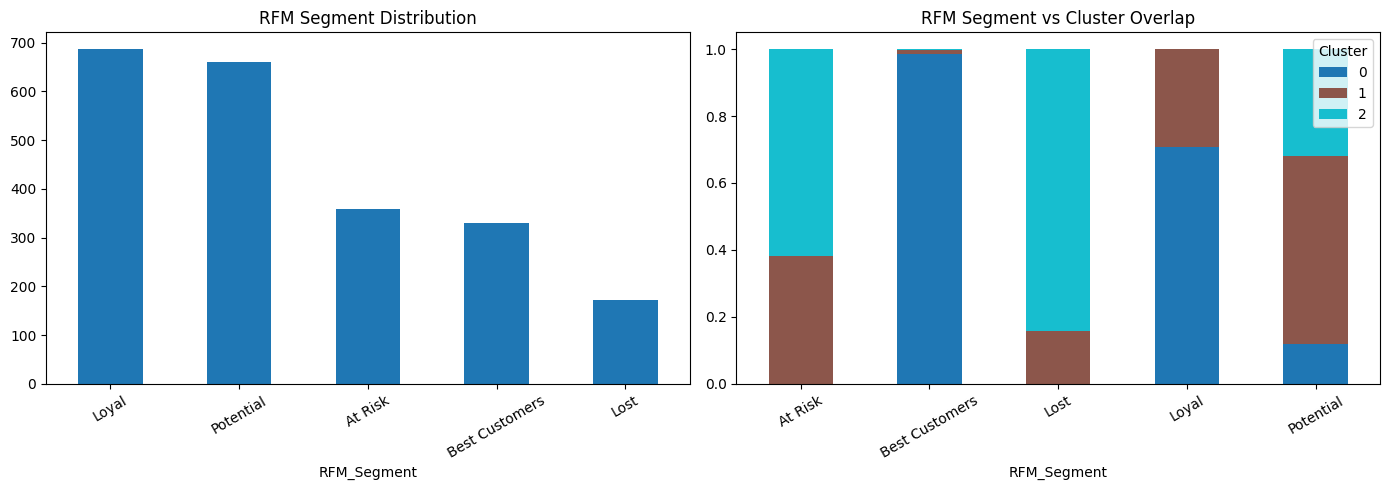

                Total_Spending  Churn_Proba  TotalAcceptedCmp
RFM_Segment                                                  
At Risk                  69.73         0.32              0.09
Best Customers         1335.60         0.00              0.67
Lost                     37.76         0.74              0.06
Loyal                   993.76         0.24              0.44
Potential               285.38         0.24              0.14


In [80]:
# Score each dimension into quintiles (1-5, 5=best)
dataset["R_Score"] = pd.qcut(dataset["Recency"], 5, labels=[5,4,3,2,1]).astype(int)
dataset["F_Score"] = pd.qcut(dataset["Total_Purchases"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
dataset["M_Score"] = pd.qcut(dataset["Total_Spending"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)

dataset["RFM_Score"] = dataset["R_Score"] + dataset["F_Score"] + dataset["M_Score"]

# Segment labels
def rfm_segment(score):
    if score >= 13: return "Best Customers"
    elif score >= 10: return "Loyal"
    elif score >= 7:  return "Potential"
    elif score >= 5:  return "At Risk"
    else:             return "Lost"

dataset["RFM_Segment"] = dataset["RFM_Score"].apply(rfm_segment)

print(dataset["RFM_Segment"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dataset["RFM_Segment"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("RFM Segment Distribution")
axes[0].tick_params(axis='x', rotation=30)

# RFM segment vs Cluster cross-tab
pd.crosstab(dataset["RFM_Segment"], dataset["Cluster"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[1], colormap="tab10"
)
axes[1].set_title("RFM Segment vs Cluster Overlap")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Mean spending and churn risk per RFM segment
print(dataset.groupby("RFM_Segment")[["Total_Spending", "Churn_Proba", "TotalAcceptedCmp"]].mean().round(2))

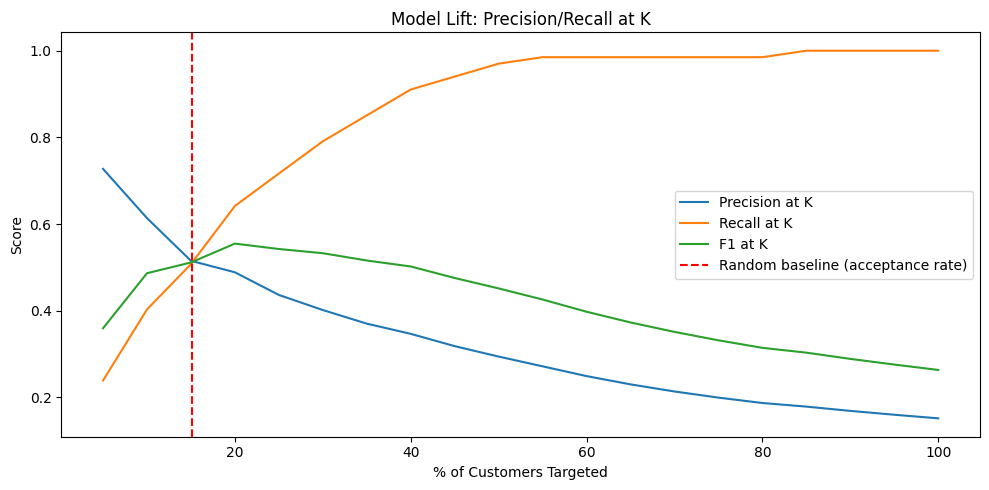

In [81]:
# Sort test set by predicted probability descending
results_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_proba": y_proba  # from your original GBM
}).sort_values("y_proba", ascending=False)

# Simulate targeting top X% of customers
thresholds = np.arange(0.05, 1.05, 0.05)
precision_at_k, recall_at_k, f1_at_k = [], [], []

for pct in thresholds:
    k = int(len(results_df) * pct)
    top_k = results_df.head(k)
    tp = top_k["y_true"].sum()
    precision = tp / k
    recall = tp / results_df["y_true"].sum()
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    precision_at_k.append(precision)
    recall_at_k.append(recall)
    f1_at_k.append(f1)

plt.figure(figsize=(10, 5))
plt.plot(thresholds * 100, precision_at_k, label="Precision at K")
plt.plot(thresholds * 100, recall_at_k, label="Recall at K")
plt.plot(thresholds * 100, f1_at_k, label="F1 at K")
plt.axvline(x=100 * results_df["y_true"].mean(), 
            color='red', linestyle='--', label='Random baseline (acceptance rate)')
plt.xlabel("% of Customers Targeted")
plt.ylabel("Score")
plt.title("Model Lift: Precision/Recall at K")
plt.legend()
plt.tight_layout()
plt.show()

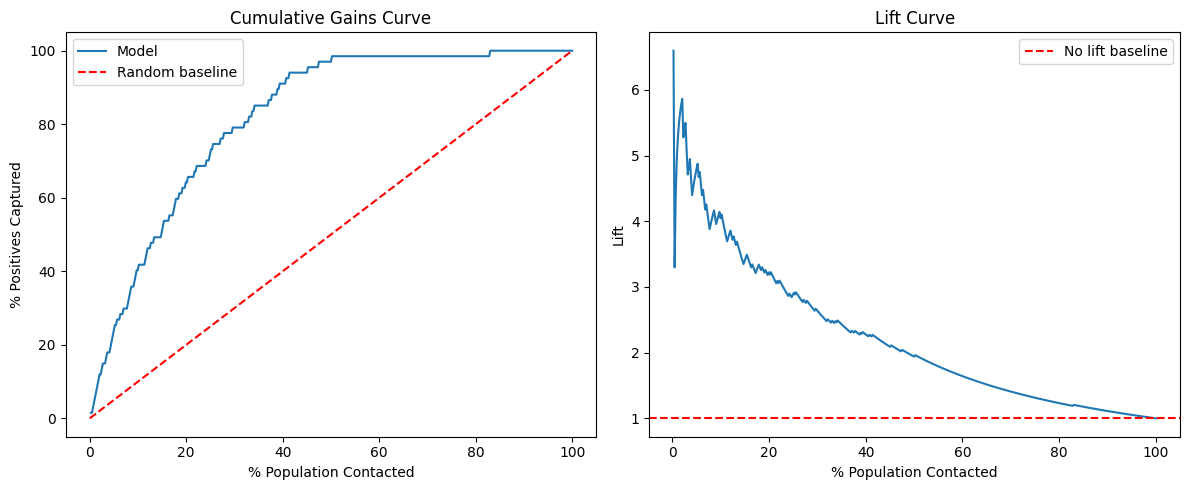

In [82]:
# Cumulative gains
results_sorted = results_df.sort_values("y_proba", ascending=False)
results_sorted["cumulative_actual"] = results_sorted["y_true"].cumsum()
results_sorted["cumulative_pct_population"] = np.arange(1, len(results_sorted)+1) / len(results_sorted)
results_sorted["cumulative_pct_positives"] = results_sorted["cumulative_actual"] / results_sorted["y_true"].sum()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_sorted["cumulative_pct_population"] * 100,
         results_sorted["cumulative_pct_positives"] * 100, label="Model")
plt.plot([0, 100], [0, 100], 'r--', label="Random baseline")
plt.xlabel("% Population Contacted")
plt.ylabel("% Positives Captured")
plt.title("Cumulative Gains Curve")
plt.legend()

# Lift curve
results_sorted["lift"] = (results_sorted["cumulative_pct_positives"] / 
                           results_sorted["cumulative_pct_population"])
plt.subplot(1, 2, 2)
plt.plot(results_sorted["cumulative_pct_population"] * 100, results_sorted["lift"])
plt.axhline(y=1, color='r', linestyle='--', label="No lift baseline")
plt.xlabel("% Population Contacted")
plt.ylabel("Lift")
plt.title("Lift Curve")
plt.legend()

plt.tight_layout()
plt.show()

Mean ARI: 0.639 +- 0.236


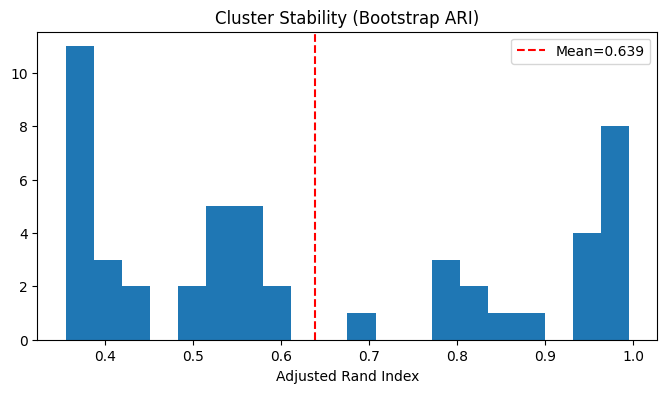

In [83]:
n_bootstrap = 50
ari_scores = []

for i in range(n_bootstrap):
    # Resample with replacement
    idx = np.random.choice(len(X_pca), len(X_pca), replace=True)
    X_boot = X_pca[idx]
    
    km_boot = KMeans(n_clusters=OPTIMAL_K, random_state=i, n_init=10)
    labels_boot = km_boot.fit_predict(X_boot)
    labels_original = km_final.predict(X_boot)
    
    ari_scores.append(adjusted_rand_score(labels_original, labels_boot))

print(f"Mean ARI: {np.mean(ari_scores):.3f} +- {np.std(ari_scores):.3f}")
plt.figure(figsize=(8, 4))
plt.hist(ari_scores, bins=20)
plt.axvline(np.mean(ari_scores), color='red', linestyle='--', label=f"Mean={np.mean(ari_scores):.3f}")
plt.title("Cluster Stability (Bootstrap ARI)")
plt.xlabel("Adjusted Rand Index")
plt.legend()
plt.show()

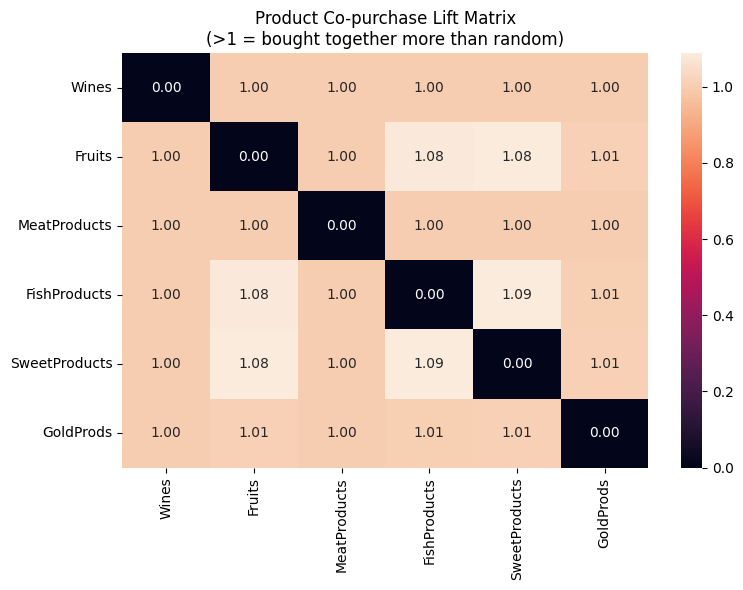

In [84]:
# Binarize product purchases
product_binary = (dataset[spending_cols] > 0).astype(int)

# Co-occurrence matrix
co_occurrence = product_binary.T.dot(product_binary)
np.fill_diagonal(co_occurrence.values, 0)

# Normalize by total buyers of each product
support = product_binary.sum()
lift_matrix = co_occurrence.div(support, axis=0).div(support, axis=1) * len(dataset)

plt.figure(figsize=(8, 6))
sns.heatmap(lift_matrix, annot=True, fmt=".2f",
            xticklabels=[c.replace("Mnt","") for c in spending_cols],
            yticklabels=[c.replace("Mnt","") for c in spending_cols])
plt.title("Product Co-purchase Lift Matrix\n(>1 = bought together more than random)")
plt.tight_layout()
plt.show()

In [85]:
# Compare KMeans vs GMM systematically
results = []

for k in range(2, 7):
    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km_labels = km.fit_predict(X_pca)
    km_sil = silhouette_score(X_pca, km_labels)
    
    # GMM
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gmm = GaussianMixture(n_components=k, random_state=42, 
                              n_init=10, covariance_type="full")
        gmm_labels = gmm.fit_predict(X_pca)
        gmm_sil = silhouette_score(X_pca, gmm_labels)
    
    results.append({
        "k": k,
        "KMeans_Silhouette": round(km_sil, 4),
        "GMM_Silhouette": round(gmm_sil, 4),
        "GMM_BIC": round(gmm.bic(X_pca), 1),
        "GMM_AIC": round(gmm.aic(X_pca), 1)
    })

results_df = pd.DataFrame(results)
print(results_df)

   k  KMeans_Silhouette  GMM_Silhouette  GMM_BIC  GMM_AIC
0  2             0.2933          0.2633  50979.9  50358.8
1  3             0.1912          0.1877  41666.6  40731.9
2  4             0.1747          0.1499  33225.6  31977.5
3  5             0.1578          0.1299  21048.9  19487.4
4  6             0.1405          0.1337  19841.8  17966.9


In [86]:
def bootstrap_stability(model_fn, X, n_bootstrap=50):
    ari_scores = []
    base_model = model_fn()
    base_labels = base_model.fit_predict(X)
    
    for i in range(n_bootstrap):
        idx = np.random.choice(len(X), len(X), replace=True)
        X_boot = X[idx]
        boot_model = model_fn()
        boot_labels = boot_model.fit_predict(X_boot)
        base_on_boot = base_model.predict(X_boot) if hasattr(base_model, 'predict') else base_labels[idx]
        ari_scores.append(adjusted_rand_score(base_on_boot, boot_labels))
    
    return np.mean(ari_scores), np.std(ari_scores)

km_fn  = lambda: KMeans(n_clusters=3, random_state=42, n_init=20)
gmm_fn = lambda: GaussianMixture(n_components=3, random_state=42, 
                                  n_init=10, covariance_type="full")

km_ari_mean,  km_ari_std  = bootstrap_stability(km_fn,  X_pca)
gmm_ari_mean, gmm_ari_std = bootstrap_stability(gmm_fn, X_pca)

print(f"KMeans ARI: {km_ari_mean:.3f} +- {km_ari_std:.3f}")
print(f"GMM ARI: {gmm_ari_mean:.3f} +- {gmm_ari_std:.3f}")

KMeans ARI: 0.703 +- 0.275
GMM ARI: 0.733 +- 0.268


In [87]:
km_all_runs = []
km_std_all_run = []
gmm_all_runs = []
gmm_std_all_run = []

for run in range(10):
    km_ari_mean,  km_ari_std = bootstrap_stability(km_fn, X_pca, n_bootstrap=50)
    gmm_ari_mean, gmm_ari_std = bootstrap_stability(gmm_fn, X_pca, n_bootstrap=50)
    km_all_runs.append(km_ari_mean)
    km_std_all_run.append(km_ari_std)
    gmm_all_runs.append(gmm_ari_mean)
    gmm_std_all_run.append(gmm_ari_std)


print(f"KMeans ARI: {np.mean(km_all_runs):.3f} +- {np.mean(km_std_all_run):.3f}")
print(f"GMM ARI: {np.mean(gmm_all_runs):.3f} +- {np.mean(gmm_std_all_run):.3f}")

KMeans ARI: 0.706 +- 0.238
GMM ARI: 0.757 +- 0.272


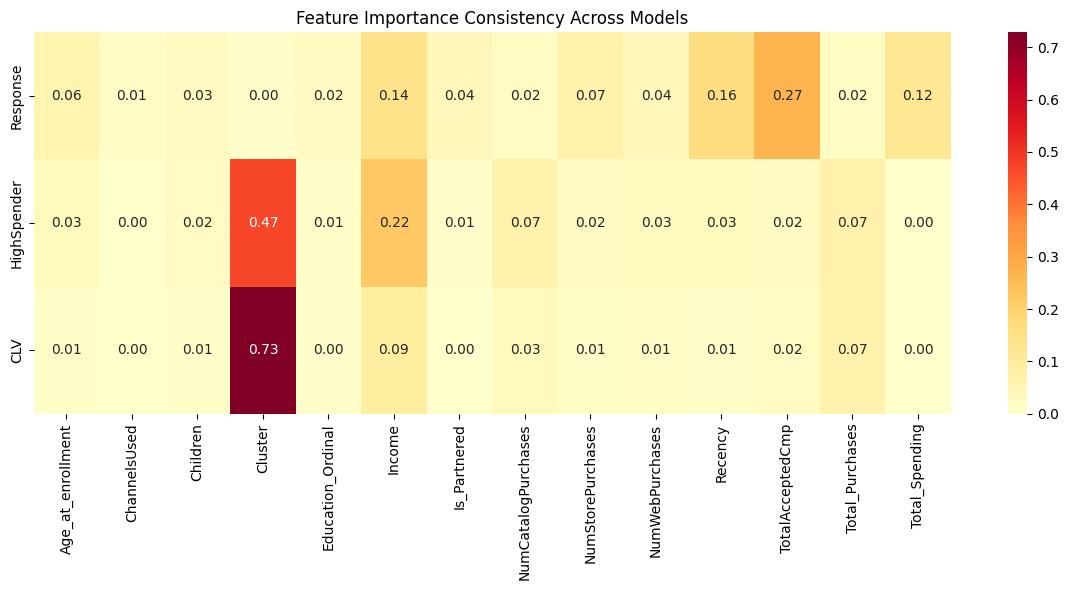

In [88]:
# Collect importances from all models into one comparison
all_importances = pd.DataFrame({
    "Response":     pd.Series(gbc.feature_importances_, index=model_features),
    "HighSpender":  pd.Series(gbc_hs.feature_importances_, index=hs_features),
    "CLV":          pd.Series(gbr_clv.feature_importances_, index=clv_features),
}).fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(all_importances.T, cmap="YlOrRd", annot=True, fmt=".2f")
plt.title("Feature Importance Consistency Across Models")
plt.tight_layout()
plt.show()

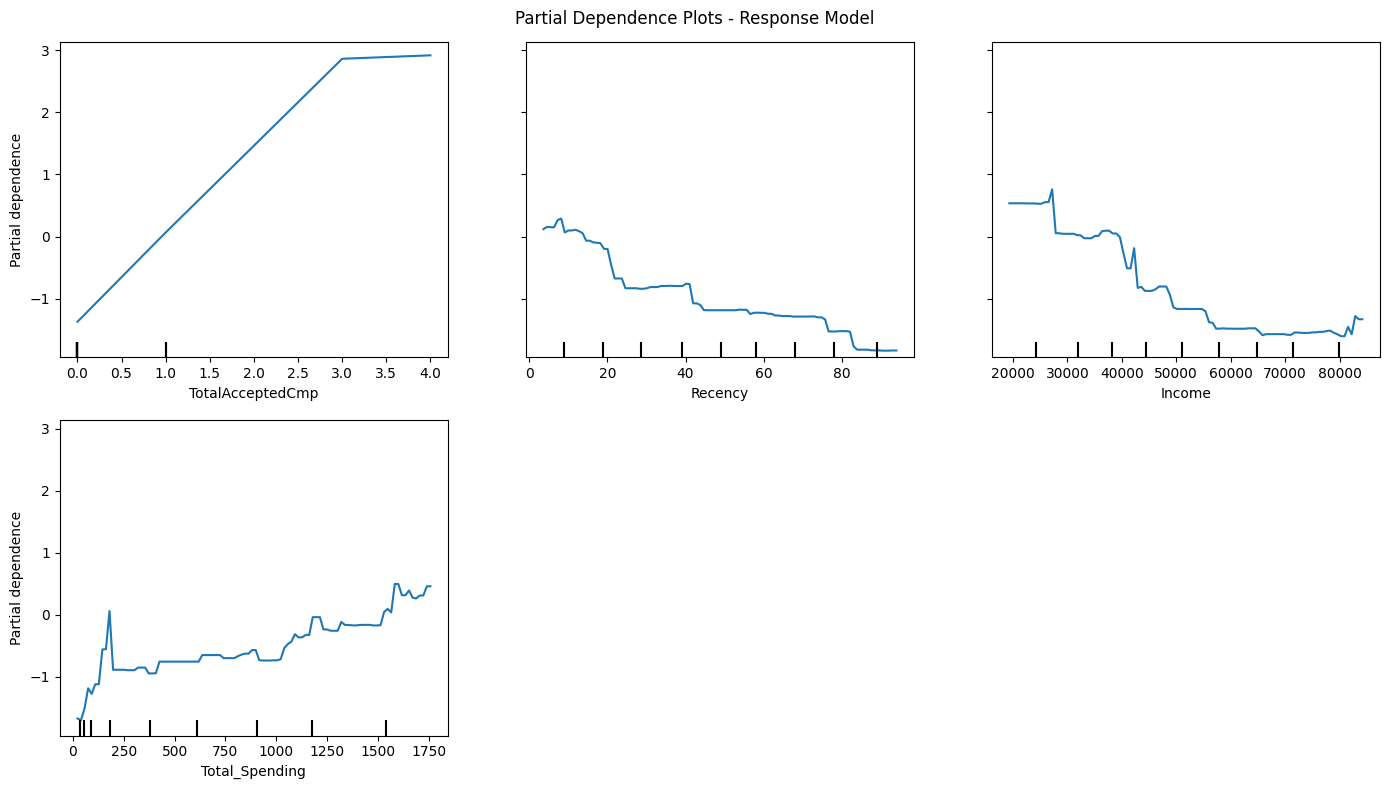

In [ ]:
top_features = feat_imp.head(4).index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))
PartialDependenceDisplay.from_estimator(
    gbc, X_train, top_features,
    kind="average",
    ax=ax
)
plt.suptitle("Partial Dependence Plots - Response Model")
plt.tight_layout()
plt.show()

In [ ]:
error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["y_proba"] = y_proba
error_df["y_pred"] = gbc.predict(X_test)
error_df["error_type"] = "Correct"
error_df.loc[(error_df["y_true"]==1) & (error_df["y_pred"]==0), "error_type"] = "False Negative"
error_df.loc[(error_df["y_true"]==0) & (error_df["y_pred"]==1), "error_type"] = "False Positive"

print(error_df["error_type"].value_counts())

profile_cols = ["Income", "Total_Spending", "Age_at_enrollment", "Recency", "Children"]
print(error_df.groupby("error_type")[profile_cols].mean().round(2))

fn = error_df[error_df["error_type"] == "False Negative"]
print(f"\nFalse Negatives - Avg Spending: {fn['Total_Spending'].mean():.2f}")
print(f"Overall Test - Avg Spending: {error_df['Total_Spending'].mean():.2f}")

error_type
Correct           383
False Negative     47
False Positive     12
Name: count, dtype: int64
                  Income  Total_Spending  Age_at_enrollment  Recency  Children
error_type                                                                    
Correct         51567.57          602.96              43.23    52.54      0.90
False Negative  59133.79          899.45              44.89    34.47      0.74
False Positive  58676.00         1037.50              45.50    25.50      1.08

False Negatives - Avg Spending: 899.45
Overall Test - Avg Spending: 646.29


In [ ]:
baseline_rate = dataset["Response"].mean()
analysis = NormalIndPower()

for lift in [0.03, 0.05, 0.08, 0.10]:
    treatment_rate = baseline_rate + lift
    
    effect_size = 2 * np.arcsin(np.sqrt(treatment_rate)) - \
                  2 * np.arcsin(np.sqrt(baseline_rate))
    
    n = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.80)
    print(f"Lift={lift:.0%}: need n={int(np.ceil(n))} per group ({int(np.ceil(n))*2} total)")

Lift=3%: need n=2410 per group (4820 total)
Lift=5%: need n=907 per group (1814 total)
Lift=8%: need n=376 per group (752 total)
Lift=10%: need n=249 per group (498 total)


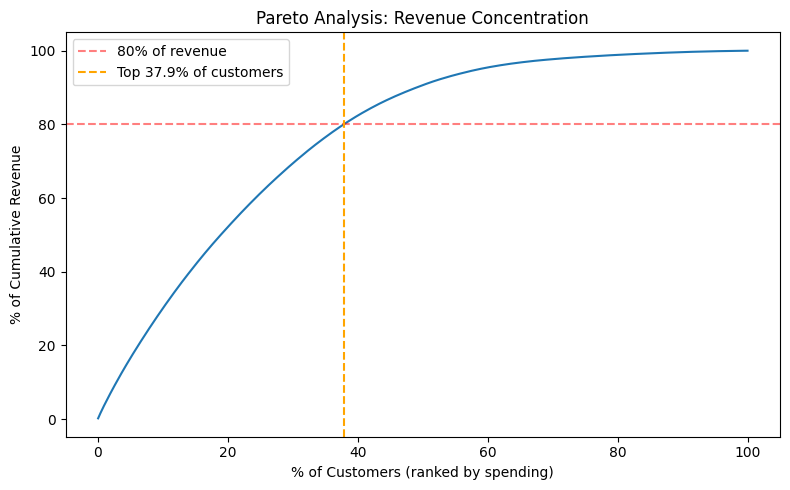

Top 37.9% of customers generate 80% of revenue


In [ ]:
dataset_sorted = dataset.sort_values("Total_Spending", ascending=False).reset_index(drop=True)
dataset_sorted["cumulative_spend_pct"] = dataset_sorted["Total_Spending"].cumsum() / dataset_sorted["Total_Spending"].sum()
dataset_sorted["customer_pct"] = (dataset_sorted.index + 1) / len(dataset_sorted)

plt.figure(figsize=(8, 5))
plt.plot(dataset_sorted["customer_pct"] * 100, dataset_sorted["cumulative_spend_pct"] * 100)
plt.axhline(80, color='red', linestyle='--', alpha=0.5, label="80% of revenue")

idx_80 = (dataset_sorted["cumulative_spend_pct"] >= 0.80).idxmax()
pct_customers = dataset_sorted.loc[idx_80, "customer_pct"] * 100
plt.axvline(pct_customers, color='orange', linestyle='--', 
            label=f"Top {pct_customers:.1f}% of customers")

plt.xlabel("% of Customers (ranked by spending)")
plt.ylabel("% of Cumulative Revenue")
plt.title("Pareto Analysis: Revenue Concentration")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Top {pct_customers:.1f}% of customers generate 80% of revenue")

In [ ]:
os.makedirs("./models", exist_ok=True)

# Preprocessing objects needed for inference
joblib.dump(scaler,    "./models/scaler.pkl")
joblib.dump(pca,       "./models/pca.pkl")
joblib.dump(le,        "./models/channel_label_encoder.pkl")
joblib.dump(le_cat,    "./models/category_label_encoder.pkl")

# Clustering
joblib.dump(km_final,  "./models/kmeans_k3.pkl")

# Classification models
joblib.dump(gbc,            "./models/response_classifier_gbc.pkl")
joblib.dump(gbc_smote,      "./models/response_classifier_gbc_smote.pkl")
joblib.dump(gbc_hs,         "./models/high_spender_classifier.pkl")
joblib.dump(gbc_sw,         "./models/sweets_buyer_classifier.pkl")
joblib.dump(xgb,            "./models/response_classifier_xgb.pkl")
joblib.dump(xgb_churn,      "./models/churn_risk_classifier.pkl")
joblib.dump(xgb_channel,    "./models/channel_preference_classifier.pkl")

# Regression models
joblib.dump(gbr_clv,        "./models/clv_regressor.pkl")

# Product propensity models (dict)
joblib.dump(propensity_models, "./models/propensity_models.pkl")

print("Saved models:")
for f in sorted(os.listdir("./models")):
    size_kb = os.path.getsize(f"./models/{f}") / 1024
    print(f"  {f:50s} {size_kb:.1f} KB")